## Loading the Dataset

In [6]:
import pickle

file_path = "../dataset/CMI_timeseries_dataset.pkl"

with open(file_path, "rb") as f:
    CMI_timeseries_dataset = pickle.load(f)
    

## Importing all the needed Libraries 

In [7]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Data Exploration

In [8]:
# Basic inspection of the loaded object

print("Object type:", type(CMI_timeseries_dataset))
print("Number of time series:", len(CMI_timeseries_dataset))

first_ts = CMI_timeseries_dataset[0]

print("\nFirst element type:", type(first_ts))
print("First time series shape:", first_ts.shape)

print("\nColumns:")
print(first_ts.columns.tolist())

print("\nFirst rows:")
display(first_ts.head())

print("\nLast rows:")
display(first_ts.tail())

Object type: <class 'list'>
Number of time series: 4437

First element type: <class 'pandas.core.frame.DataFrame'>
First time series shape: (200, 13)

Columns:
['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']

First rows:


,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0



Last rows:


,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
195,0.217219,-0.049072,-0.677605,0.023341,-48.641335,0.0,23.635958,4000.0,4.0,4.0,253.0,2265,0
196,-0.114495,0.255887,-0.221531,0.043775,-15.998703,0.0,0.424431,4000.0,4.0,4.0,253.0,2265,0
197,-0.330821,0.617914,0.084195,0.021643,5.085504,0.0,0.023987,4000.0,4.0,4.0,253.0,2265,0
198,-0.074080,0.543216,-0.031553,0.017400,-2.606687,0.0,0.041618,4000.0,4.0,4.0,253.0,2265,0
199,0.080657,0.130051,-0.424640,0.025921,-30.775494,0.0,0.057038,4000.0,4.0,4.0,253.0,2265,0


### Initial inspection of the time-series dataset

The loaded object is a Python list containing 4,437 elements. Each element of the list corresponds to one subject and is represented as a `pandas.DataFrame`.

The first time series has shape `(200, 13)`, meaning that it contains 200 time steps and 13 variables. Since the data were aggregated over 30-minute intervals, each row represents one time interval for a given subject.

The dataset is therefore not a standard tabular dataset where each row is an independent subject. Instead, it is a collection of time series, one for each subject. This is important because clustering, classification, motif discovery and anomaly detection must preserve the temporal structure of the data.

The variables are:

- `X`, `Y`, `Z`: accelerometer signals along the three spatial axes. They describe movement patterns of the subject/device over time.
- `enmo`: Euclidean Norm Minus One, a derived accelerometer measure commonly used as a proxy for physical activity intensity.
- `anglez`: angle of the device with respect to the vertical axis; it provides information about posture/orientation.
- `non-wear_flag`: binary indicator identifying time intervals in which the device was likely not worn. These observations may be unreliable and should be carefully checked during preprocessing.
- `light`: ambient light exposure recorded by the device.
- `battery_voltage`: battery level/voltage of the device. This is mostly device-related rather than behavioral, but it can be useful to identify technical issues.
- `weekday`: day of the week associated with the observation.
- `quarter`: time-of-day interval, probably representing the quarter of the day or a discretized temporal segment.
- `relative_date_PCIAT`: relative date with respect to the PCIAT assessment/reference date.
- `id`: subject identifier. This variable should not be used as an input feature for classification or clustering, because it only identifies the subject.
- `sii_binary`: binary target variable derived from the Severity Impairment Index. It distinguishes non-problematic subjects from problematic subjects.

For the following analyses, we need to separate signal variables, metadata variables and the target variable. In particular, `sii_binary` must be used only as the target in supervised classification, while `id` must be excluded from the input features to avoid subject-identification leakage.

Before applying the Module 3 tasks, we need to verify that all time series have the same structure, analyze missing values, identify anomalous observations and decide how to preprocess the signals.

In [9]:
# Check whether all time series have the same structure

structure = []

for i, ts in enumerate(CMI_timeseries_dataset):
    structure.append({
        "series_index": i,
        "n_rows": ts.shape[0],
        "n_cols": ts.shape[1],
        "columns": tuple(ts.columns)
    })

structure_df = pd.DataFrame(structure)

print("Number of time series:", len(structure_df))
print("\nRows distribution:")
display(structure_df["n_rows"].value_counts().sort_index())

print("\nColumns distribution:")
display(structure_df["n_cols"].value_counts().sort_index())

print("\nNumber of different column structures:", structure_df["columns"].nunique())

display(structure_df.head())

Number of time series: 4437

Rows distribution:


n_rows
200    4437
Name: count, dtype: int64


Columns distribution:


n_cols
13    4437
Name: count, dtype: int64


Number of different column structures: 1


,series_index,n_rows,n_cols,columns
0,0,200,13,"(X, Y, Z, enmo, anglez, non-wear_flag, light, ..."
1,1,200,13,"(X, Y, Z, enmo, anglez, non-wear_flag, light, ..."
2,2,200,13,"(X, Y, Z, enmo, anglez, non-wear_flag, light, ..."
3,3,200,13,"(X, Y, Z, enmo, anglez, non-wear_flag, light, ..."
4,4,200,13,"(X, Y, Z, enmo, anglez, non-wear_flag, light, ..."


### Verification of time-series structure

The structure check shows that all 4,437 time series have the same shape: each subject is represented by 200 time steps and 13 variables. Moreover, there is only one column structure across the whole dataset, meaning that all time series contain the same variables in the same order.

This is an important preliminary result because it confirms that the dataset is already temporally aligned and structurally consistent. Therefore, no padding, truncation, resampling or column harmonization is required before applying time-series methods.

From a practical point of view, this allows us to safely transform the list of DataFrames into a three-dimensional array of the form:

`n_subjects × n_time_steps × n_variables`

In this case, the full structure would be:

`4437 × 200 × 13`

However, not all 13 variables should necessarily be used as input signals. In particular, `id` is an identifier and `sii_binary` is the target variable, so they must be excluded from the feature set for clustering and classification tasks.

In [10]:
# Define target, identifier, metadata and signal columns

target_col = "sii_binary"
id_col = "id"

all_columns = CMI_timeseries_dataset[0].columns.tolist()

metadata_cols = [
    "non-wear_flag",
    "battery_voltage",
    "weekday",
    "quarter",
    "relative_date_PCIAT",
    id_col,
    target_col
]

signal_cols = [
    col for col in all_columns
    if col not in metadata_cols
]

print("All columns:")
print(all_columns)

print("\nTarget column:")
print(target_col)

print("\nIdentifier column:")
print(id_col)

print("\nMetadata / contextual columns:")
print(metadata_cols)

print("\nSelected signal columns:")
print(signal_cols)

print("\nNumber of selected signal columns:", len(signal_cols))

All columns:
['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']

Target column:
sii_binary

Identifier column:
id

Metadata / contextual columns:
['non-wear_flag', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']

Selected signal columns:
['X', 'Y', 'Z', 'enmo', 'anglez', 'light']

Number of selected signal columns: 6


### Selection of input signals, metadata and target variable

After inspecting the dataset columns, we separated the variables according to their role in the analysis.

The target variable is `sii_binary`, which represents the binarized Severity Impairment Index. This variable will be used only in supervised classification tasks and must not be included among the input features.

The identifier variable is `id`, which uniquely identifies each subject. This column must also be excluded from the input features because it does not represent a behavioral or temporal signal and could introduce subject-identification leakage.

The metadata and contextual variables are:

- `non-wear_flag`: indicates intervals in which the device was likely not worn.
- `battery_voltage`: device-related information.
- `weekday`: day-of-week information.
- `quarter`: temporal segment of the day.
- `relative_date_PCIAT`: relative date with respect to the reference PCIAT assessment.
- `id`: subject identifier.
- `sii_binary`: target variable.

For the first phase of exploration and preprocessing, we selected the following six signal variables:

- `X`
- `Y`
- `Z`
- `enmo`
- `anglez`
- `light`

These variables describe the actual time-dependent measurements related to movement, orientation and light exposure. Therefore, they are the most appropriate initial input signals for time-series analysis, including missing-value analysis, outlier detection, motif/discord discovery, clustering and classification.

This separation is necessary to avoid using non-informative identifiers or the target variable as input features, and to keep the preprocessing focused on the real temporal signals.

Number of subjects: 4437

Number of unique target values within each time series:


n_unique_target_values
1    4437
Name: count, dtype: int64


Target distribution:


target_value
0    2957
1    1480
Name: count, dtype: int64

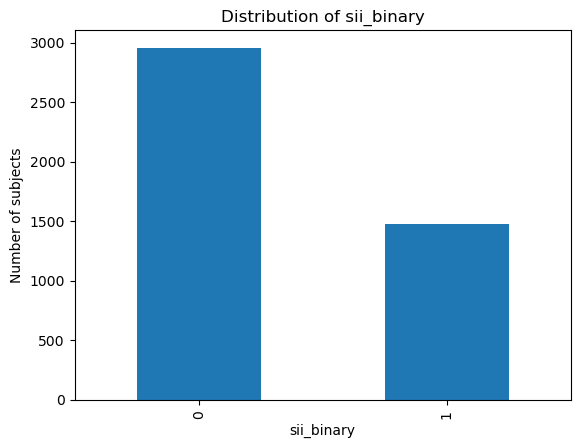

In [11]:
# Analyze the distribution of the binary target variable

target_values = []

for i, ts in enumerate(CMI_timeseries_dataset):
    # The target should be constant within each subject's time series
    unique_targets = ts[target_col].dropna().unique()
    
    target_values.append({
        "series_index": i,
        "n_unique_target_values": len(unique_targets),
        "target_value": unique_targets[0] if len(unique_targets) > 0 else np.nan
    })

target_df = pd.DataFrame(target_values)

print("Number of subjects:", len(target_df))

print("\nNumber of unique target values within each time series:")
display(target_df["n_unique_target_values"].value_counts().sort_index())

print("\nTarget distribution:")
display(target_df["target_value"].value_counts(dropna=False).sort_index())

target_df["target_value"].value_counts(dropna=False).sort_index().plot(kind="bar")
plt.title("Distribution of sii_binary")
plt.xlabel("sii_binary")
plt.ylabel("Number of subjects")
plt.show()

### Target variable distribution

The target variable `sii_binary` is constant within each time series: every subject has exactly one target value repeated across the 200 time steps. This confirms that `sii_binary` is a subject-level label rather than a time-dependent signal.

The binary target distribution is:

- Class `0`: 2,957 subjects
- Class `1`: 1,480 subjects

Therefore, the dataset is moderately imbalanced: class `0` is approximately twice as frequent as class `1`. This imbalance is not extreme, but it must be considered when evaluating classification models.

For this reason, accuracy alone may be misleading. In the classification phase, it will be more appropriate to use evaluation metrics such as balanced accuracy, precision, recall, F1-score and the confusion matrix.

For unsupervised tasks such as clustering and motif/discord discovery, `sii_binary` must not be used as an input feature. However, it can be used afterwards to interpret whether the discovered clusters or temporal patterns are associated with problematic or non-problematic subjects.

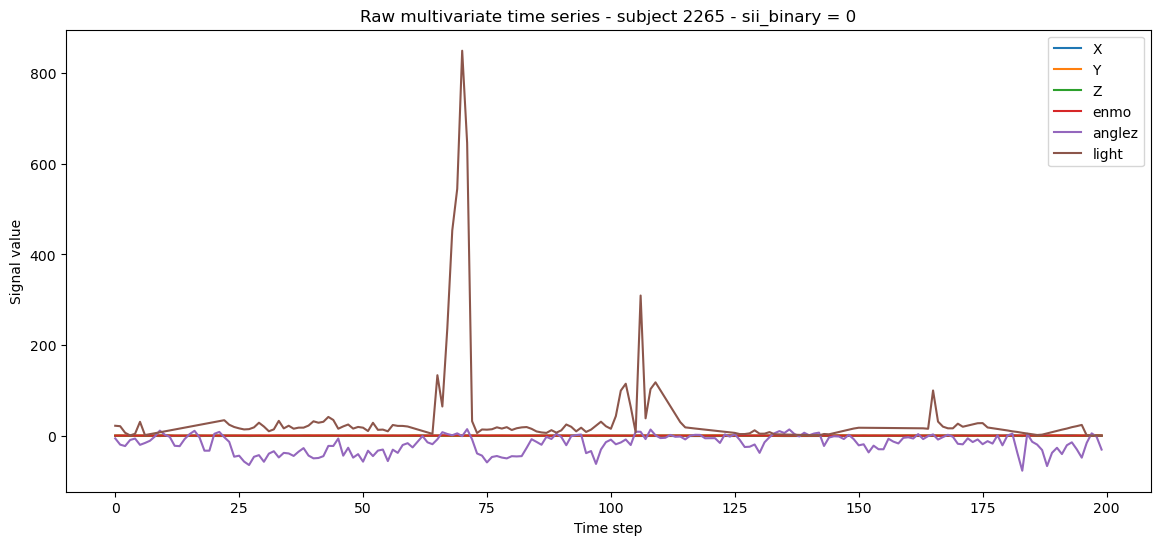

In [12]:
# Visualize one example time series using the selected signal columns

example_idx = 0
example_ts = CMI_timeseries_dataset[example_idx]

plt.figure(figsize=(14, 6))

for col in signal_cols:
    plt.plot(example_ts.index, example_ts[col], label=col)

plt.title(f"Raw multivariate time series - subject {example_ts[id_col].iloc[0]} - sii_binary = {example_ts[target_col].iloc[0]}")
plt.xlabel("Time step")
plt.ylabel("Signal value")
plt.legend()
plt.show()

### First raw time-series visualization

The first visualization shows the six selected signal variables for one subject (`X`, `Y`, `Z`, `enmo`, `anglez`, and `light`) over the 200 time steps.

The plot confirms that the data have a clear temporal structure: each variable changes over time for the same subject. However, plotting all signals on the same axis is only partially informative because the variables have very different numerical scales.

In particular, the `light` variable reaches much larger values than the accelerometer-related variables and dominates the plot. As a consequence, the dynamics of `X`, `Y`, `Z`, and `enmo` are compressed around zero and are difficult to inspect visually. The `anglez` variable is also on a different scale and can take negative values.

This suggests that, for the following exploratory analysis, it is useful to visualize each signal separately or to standardize the signals before plotting them together. The large peaks in `light` may represent real exposure events or potential anomalous observations, but this requires a systematic missing-value and outlier analysis across all subjects.

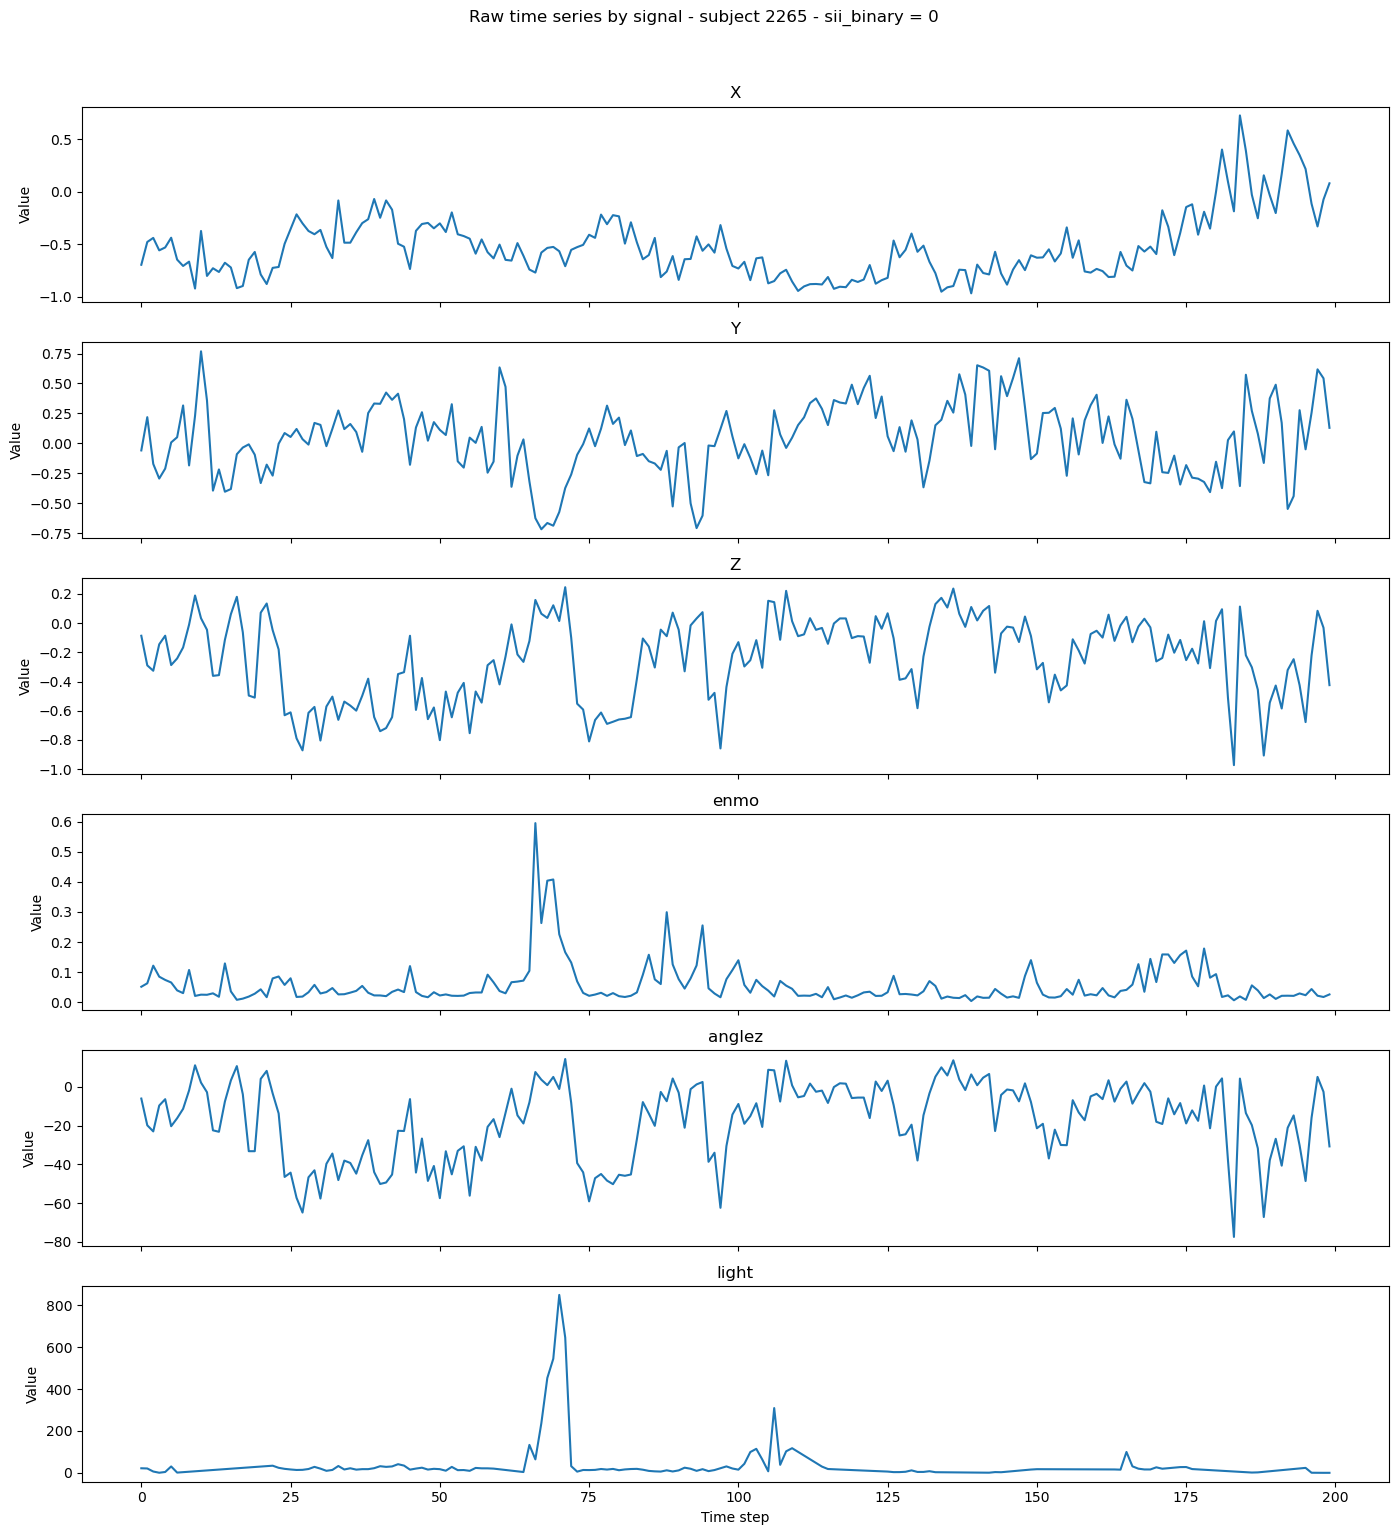

In [13]:
# Visualize one example time series with one subplot per signal

example_idx = 0
example_ts = CMI_timeseries_dataset[example_idx]

fig, axes = plt.subplots(
    nrows=len(signal_cols),
    ncols=1,
    figsize=(14, 2.5 * len(signal_cols)),
    sharex=True
)

for ax, col in zip(axes, signal_cols):
    ax.plot(example_ts.index, example_ts[col])
    ax.set_title(col)
    ax.set_ylabel("Value")

axes[-1].set_xlabel("Time step")

fig.suptitle(
    f"Raw time series by signal - subject {example_ts[id_col].iloc[0]} - sii_binary = {example_ts[target_col].iloc[0]}",
    y=1.02
)

plt.tight_layout()
plt.show()

### Visualization of individual time-series signals

The second visualization plots each selected signal separately for the same subject. This representation is more informative than plotting all variables on the same axis, because each variable has its own numerical range and scale.

The accelerometer axes (`X`, `Y`, and `Z`) show continuous variation over time and capture movement or device-orientation dynamics. The `enmo` signal is mostly close to zero, but it presents some clear peaks, suggesting intervals of higher activity intensity. The `anglez` variable shows large negative values and seems related to the orientation of the device. The `light` variable has a highly skewed behavior: most values are relatively low, but a few time intervals show very large peaks.

This confirms that the selected signals have different distributions and scales. Consequently, standardization or normalization will be required before applying distance-based methods such as KNN or clustering. At the same time, large peaks should not be automatically removed, because they may represent real behavioral events rather than errors. For this reason, missing values and outliers should be analyzed systematically across all subjects before applying preprocessing transformations.

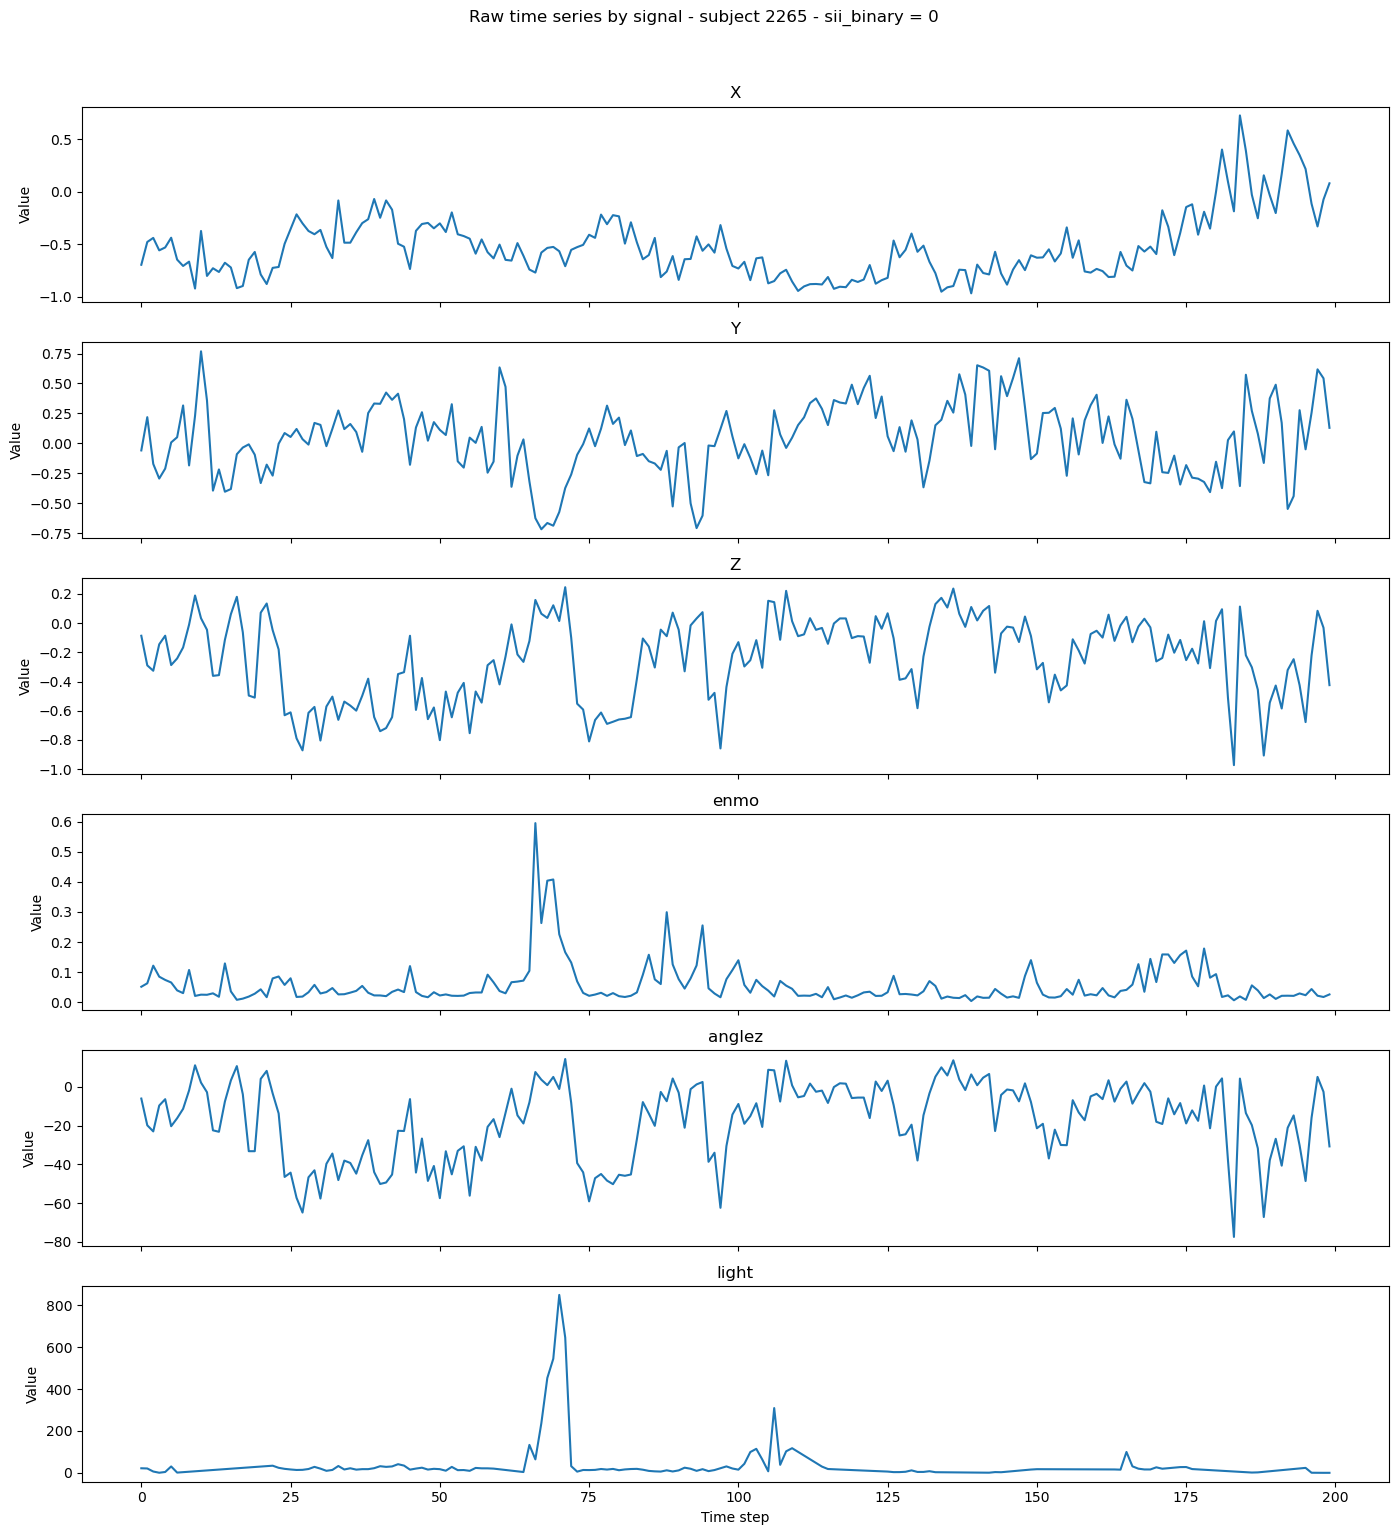

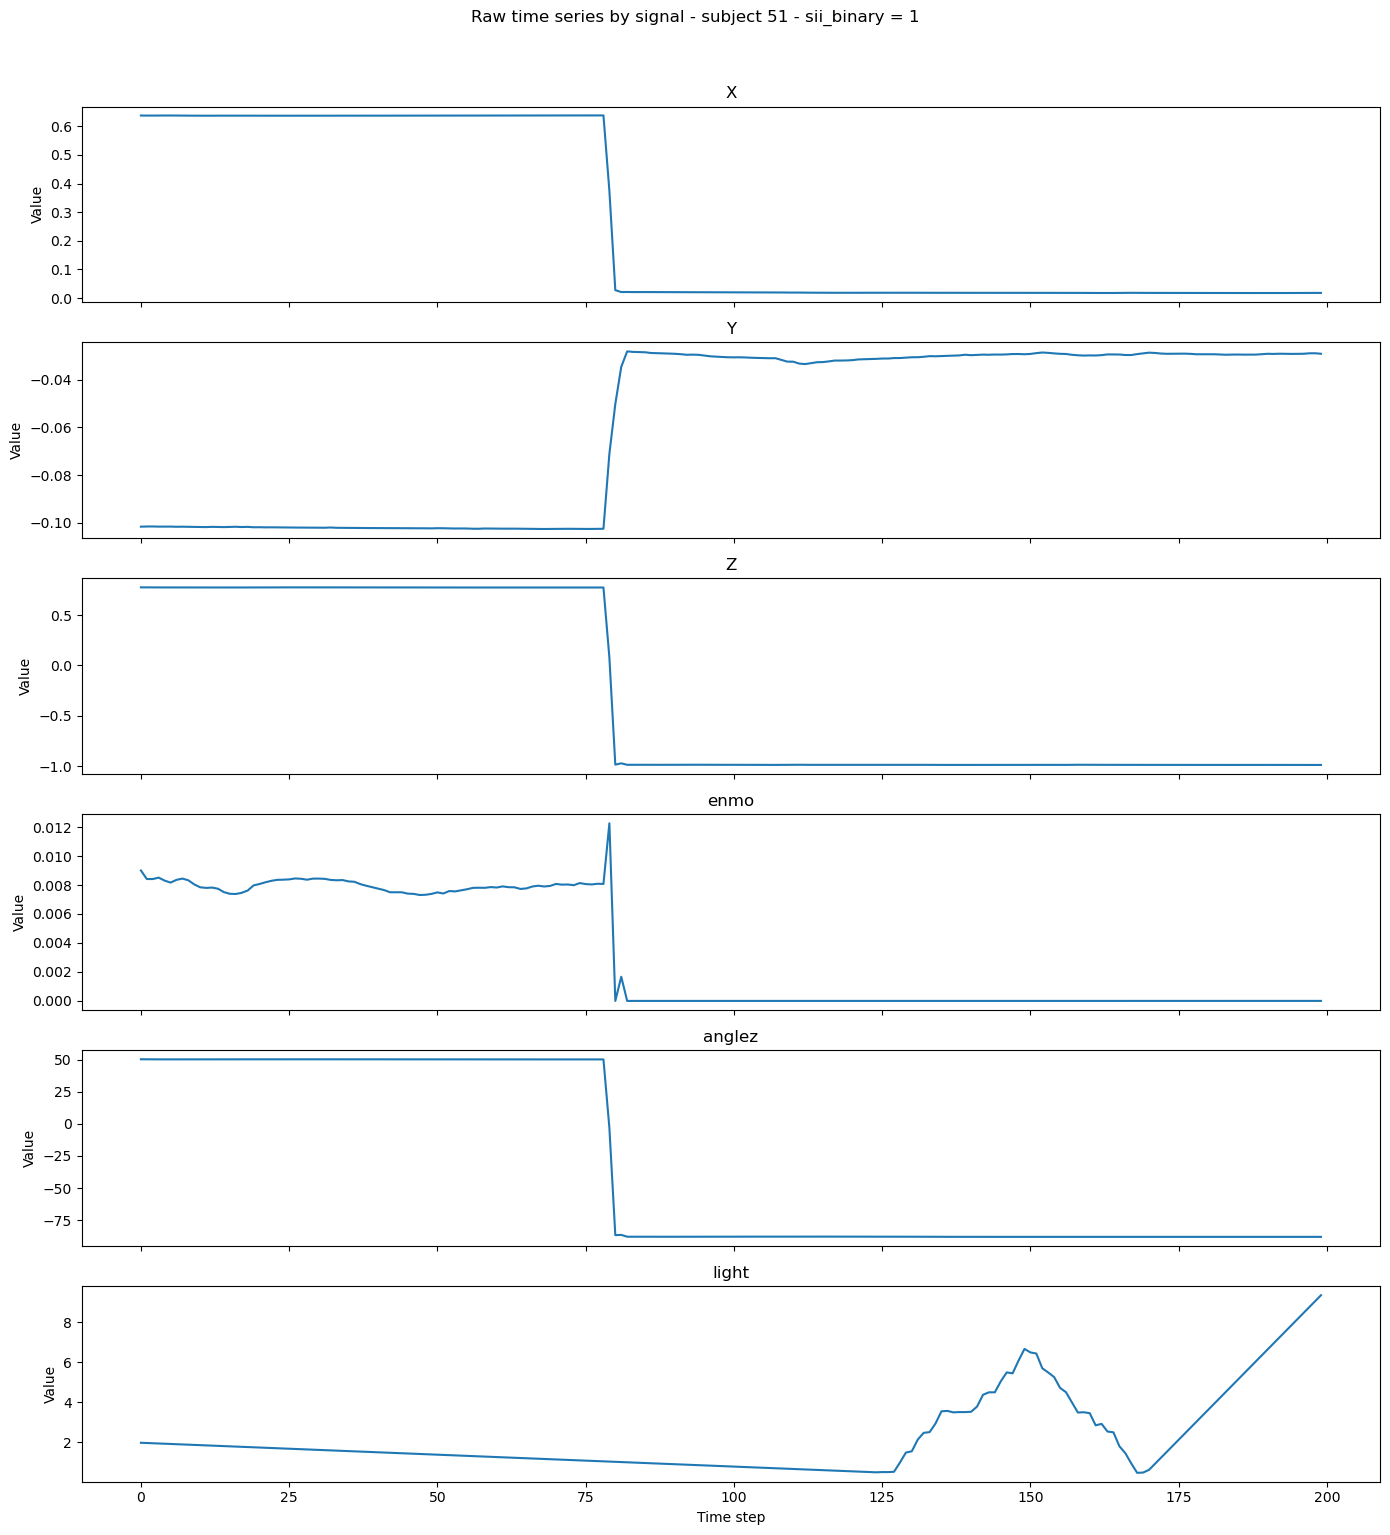

In [14]:
# Visualize one subject from each class

class_0_idx = target_df[target_df["target_value"] == 0]["series_index"].iloc[0]
class_1_idx = target_df[target_df["target_value"] == 1]["series_index"].iloc[0]

example_indices = [class_0_idx, class_1_idx]

for example_idx in example_indices:
    example_ts = CMI_timeseries_dataset[example_idx]
    
    fig, axes = plt.subplots(
        nrows=len(signal_cols),
        ncols=1,
        figsize=(14, 2.5 * len(signal_cols)),
        sharex=True
    )

    for ax, col in zip(axes, signal_cols):
        ax.plot(example_ts.index, example_ts[col])
        ax.set_title(col)
        ax.set_ylabel("Value")

    axes[-1].set_xlabel("Time step")

    fig.suptitle(
        f"Raw time series by signal - subject {example_ts[id_col].iloc[0]} - sii_binary = {example_ts[target_col].iloc[0]}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

### Visual comparison between one subject from each class

We visualized one example subject from class `0` and one example subject from class `1`. This provides an initial qualitative comparison between non-problematic and problematic subjects, but it should not be interpreted as evidence of general class-level differences, because only two individual cases are shown.

The class `0` example shows more irregular temporal variation across the accelerometer-related signals. The `enmo` signal presents visible peaks, suggesting intervals of higher movement intensity, while the `light` signal contains a large spike around the middle of the sequence.

The class `1` example appears much more piecewise-constant. Several signals show an abrupt change around the middle of the sequence and then remain almost flat. In particular, `enmo` becomes close to zero after the change point, which may indicate very low movement intensity, but it may also suggest a sensor or data-quality issue.

This comparison highlights that the dataset contains heterogeneous temporal profiles. Some time series may include abrupt changes, flat segments or strong peaks. Therefore, before applying clustering, motif/discord discovery or classification methods, we need to systematically analyze missing values, non-wear intervals and potential anomalous observations across all subjects.

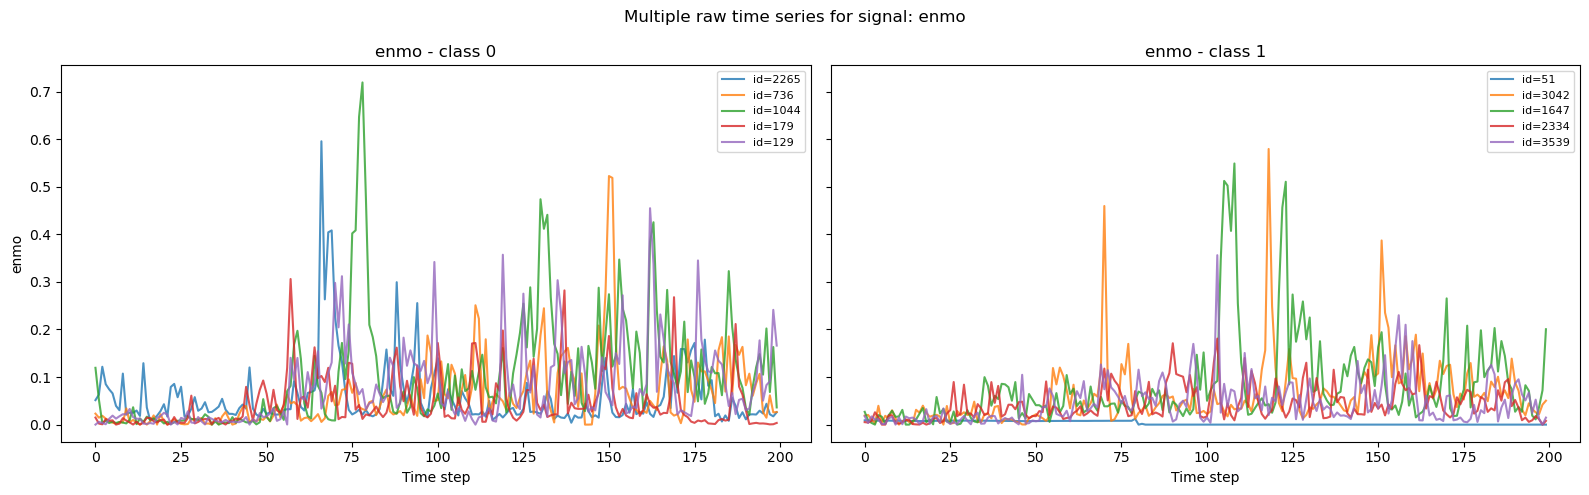

In [15]:
# Visualize multiple time series for one selected signal, grouped by class

signal_to_plot = "enmo"
n_examples_per_class = 5

class_0_indices = target_df[target_df["target_value"] == 0]["series_index"].head(n_examples_per_class).tolist()
class_1_indices = target_df[target_df["target_value"] == 1]["series_index"].head(n_examples_per_class).tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for idx in class_0_indices:
    ts = CMI_timeseries_dataset[idx]
    axes[0].plot(ts.index, ts[signal_to_plot], alpha=0.8, label=f"id={ts[id_col].iloc[0]}")

axes[0].set_title(f"{signal_to_plot} - class 0")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel(signal_to_plot)
axes[0].legend(fontsize=8)

for idx in class_1_indices:
    ts = CMI_timeseries_dataset[idx]
    axes[1].plot(ts.index, ts[signal_to_plot], alpha=0.8, label=f"id={ts[id_col].iloc[0]}")

axes[1].set_title(f"{signal_to_plot} - class 1")
axes[1].set_xlabel("Time step")
axes[1].legend(fontsize=8)

plt.suptitle(f"Multiple raw time series for signal: {signal_to_plot}")
plt.tight_layout()
plt.show()

### Visualization of multiple `enmo` time series by class

We visualized multiple raw time series for the `enmo` signal, separately for class `0` and class `1`. The `enmo` variable is particularly relevant because it is a proxy for movement or activity intensity.

In both classes, most values are close to zero, with occasional peaks corresponding to intervals of higher activity. This suggests that activity is generally sparse over time, with short bursts of movement rather than continuously high intensity.

From this qualitative visualization, there is no clear visual separation between class `0` and class `1`. Both groups include subjects with low baseline activity and occasional high peaks. Therefore, the classification task is unlikely to be solved by a simple visual threshold on `enmo` alone.

At the same time, the plot highlights substantial heterogeneity across subjects: the number, magnitude and timing of activity peaks vary from one subject to another. This supports the use of time-series methods such as motif/discord discovery, clustering with appropriate distances, shapelets, and time-series classification algorithms.

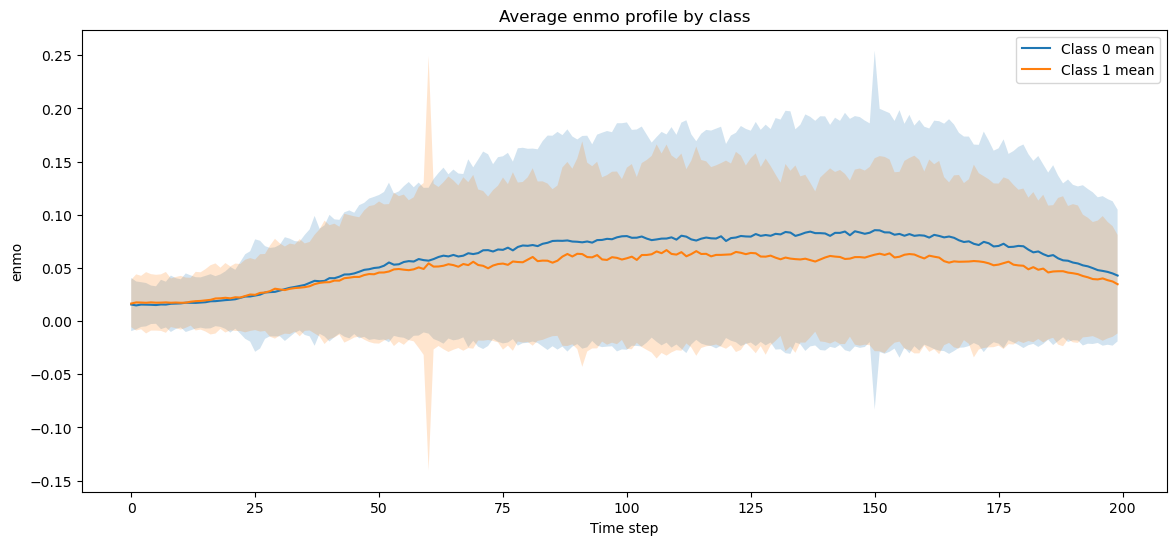

In [16]:
# Average profile by class for one selected signal

signal_to_plot = "enmo"

class_0_indices = target_df[target_df["target_value"] == 0]["series_index"].tolist()
class_1_indices = target_df[target_df["target_value"] == 1]["series_index"].tolist()

X0_signal = np.array([
    CMI_timeseries_dataset[idx][signal_to_plot].values
    for idx in class_0_indices
])

X1_signal = np.array([
    CMI_timeseries_dataset[idx][signal_to_plot].values
    for idx in class_1_indices
])

mean_0 = np.nanmean(X0_signal, axis=0)
std_0 = np.nanstd(X0_signal, axis=0)

mean_1 = np.nanmean(X1_signal, axis=0)
std_1 = np.nanstd(X1_signal, axis=0)

time_steps = np.arange(len(mean_0))

plt.figure(figsize=(14, 6))

plt.plot(time_steps, mean_0, label="Class 0 mean")
plt.fill_between(time_steps, mean_0 - std_0, mean_0 + std_0, alpha=0.2)

plt.plot(time_steps, mean_1, label="Class 1 mean")
plt.fill_between(time_steps, mean_1 - std_1, mean_1 + std_1, alpha=0.2)

plt.title(f"Average {signal_to_plot} profile by class")
plt.xlabel("Time step")
plt.ylabel(signal_to_plot)
plt.legend()
plt.show()

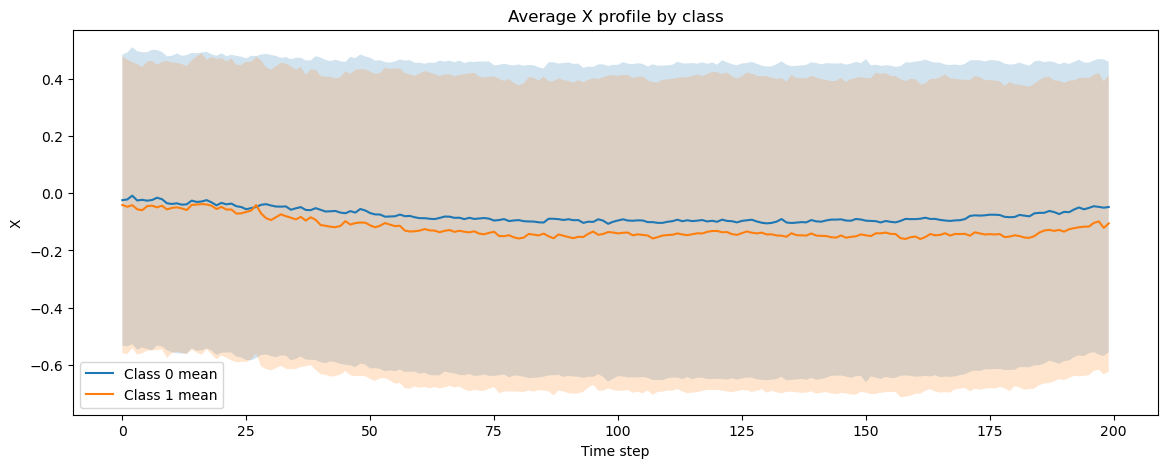

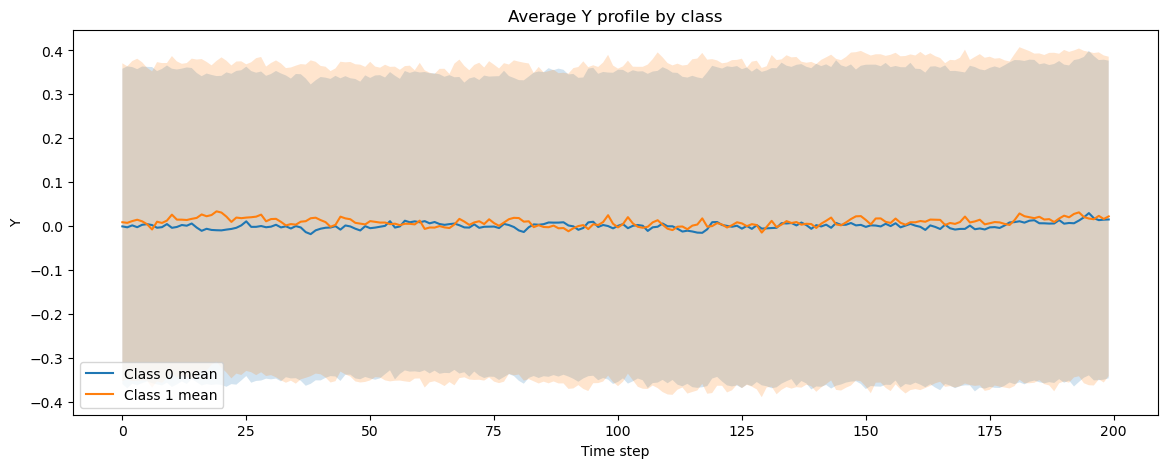

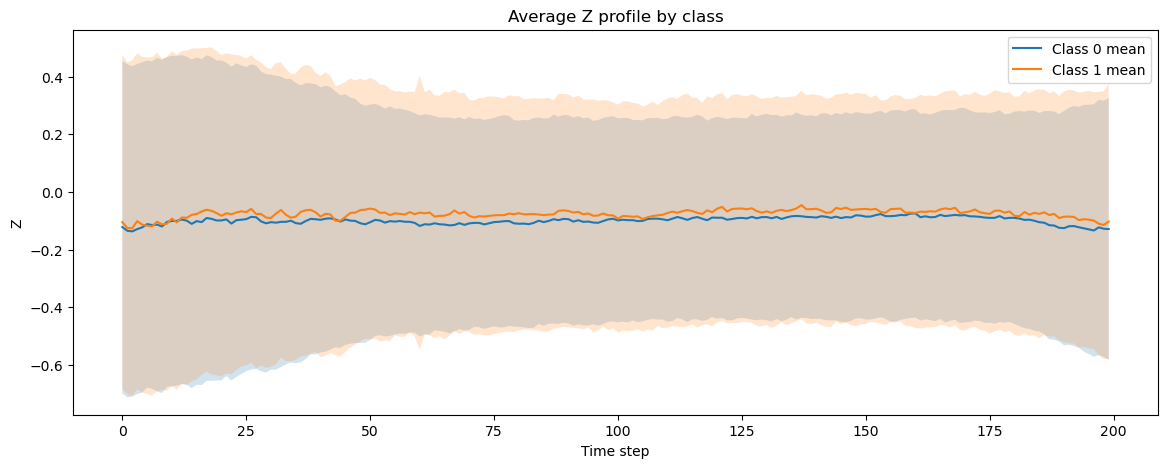

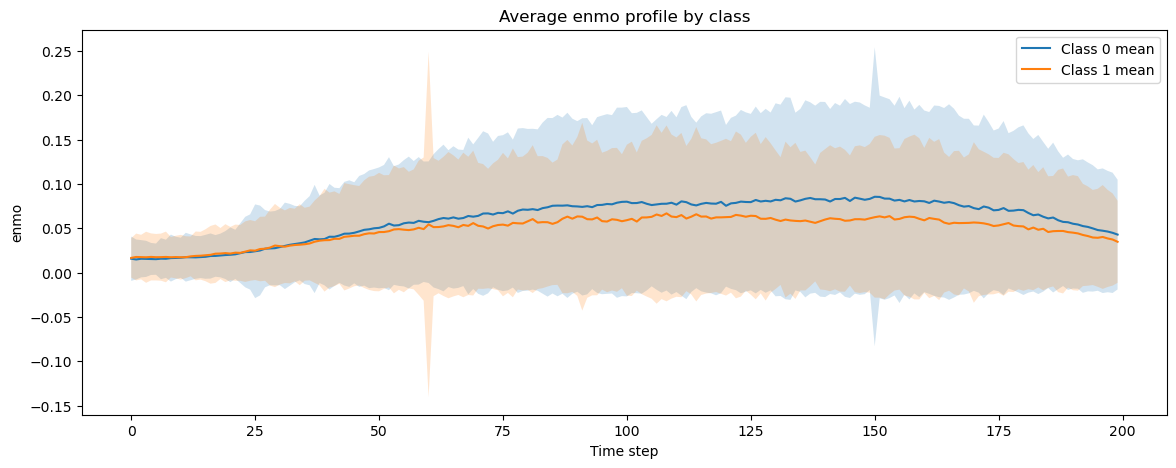

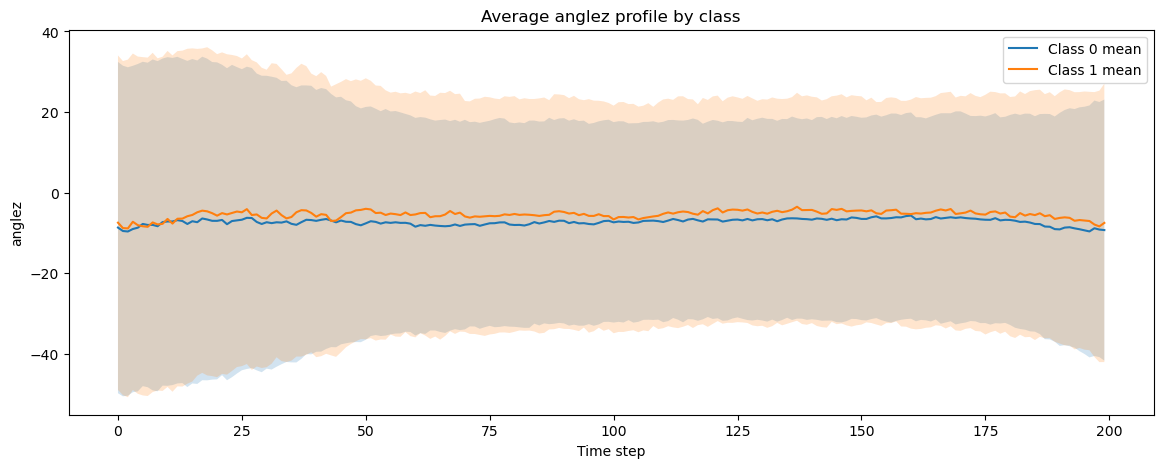

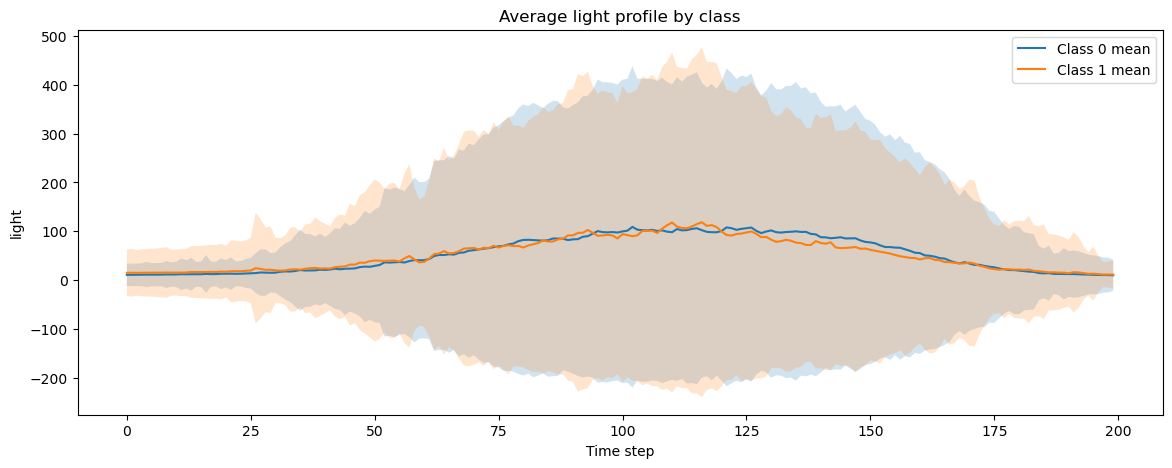

In [17]:
# Average profile by class for all selected signal variables

class_0_indices = target_df[target_df["target_value"] == 0]["series_index"].tolist()
class_1_indices = target_df[target_df["target_value"] == 1]["series_index"].tolist()

for signal_to_plot in signal_cols:
    
    X0_signal = np.array([
        CMI_timeseries_dataset[idx][signal_to_plot].values
        for idx in class_0_indices
    ])

    X1_signal = np.array([
        CMI_timeseries_dataset[idx][signal_to_plot].values
        for idx in class_1_indices
    ])

    mean_0 = np.nanmean(X0_signal, axis=0)
    std_0 = np.nanstd(X0_signal, axis=0)

    mean_1 = np.nanmean(X1_signal, axis=0)
    std_1 = np.nanstd(X1_signal, axis=0)

    time_steps = np.arange(len(mean_0))

    plt.figure(figsize=(14, 5))

    plt.plot(time_steps, mean_0, label="Class 0 mean")
    plt.fill_between(time_steps, mean_0 - std_0, mean_0 + std_0, alpha=0.2)

    plt.plot(time_steps, mean_1, label="Class 1 mean")
    plt.fill_between(time_steps, mean_1 - std_1, mean_1 + std_1, alpha=0.2)

    plt.title(f"Average {signal_to_plot} profile by class")
    plt.xlabel("Time step")
    plt.ylabel(signal_to_plot)
    plt.legend()
    plt.show()

### Average signal profiles by class

We computed and visualized the average temporal profile of each selected signal separately for class `0` and class `1`. The shaded regions represent one standard deviation around the class-specific mean and provide information about the variability across subjects.

The accelerometer axes (`X`, `Y`, `Z`) and the orientation variable `anglez` show very large variability bands and strong overlap between the two classes. Their average trajectories are relatively close, suggesting that these raw signals do not provide an obvious visual separation between problematic and non-problematic subjects.

The `Y` signal is almost centered around zero for both classes and the two average profiles are nearly identical. The `Z` and `anglez` signals appear related, which is expected because both are connected to device orientation. This may indicate partial redundancy between these variables.

The `enmo` signal is more informative from an exploratory point of view. Class `0` shows a slightly higher average activity intensity than class `1`, especially in the central part of the sequence. However, the standard deviation bands overlap substantially, meaning that this difference is not strong enough to separate the classes by itself.

The `light` variable shows a clear temporal pattern, with values increasing toward the middle of the sequence and decreasing afterwards. This may reflect a daily exposure pattern. The two classes have similar average light profiles and again show strong overlap.

Overall, these visualizations suggest that there is no single raw signal that clearly separates the two classes. The differences between classes are subtle and embedded in highly variable temporal profiles. This supports the need for more systematic time-series methods, such as motif/discord discovery, clustering with appropriate distances, shapelet analysis and time-series classification algorithms.

Missing value summary across subjects:


count    4437.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: missing_ratio, dtype: float64


Number of subjects with at least one missing value:
0

Top 10 subjects by missing ratio:


,series_index,subject_id,target,n_missing,missing_ratio
0,0,2265,0,0,0.0
2957,2957,3648,0,0,0.0
2963,2963,580,1,0,0.0
2962,2962,1235,0,0,0.0
2961,2961,1246,0,0,0.0
2960,2960,634,0,0,0.0
2959,2959,1017,1,0,0.0
2958,2958,2730,1,0,0.0
2956,2956,1044,0,0,0.0
2948,2948,300,1,0,0.0


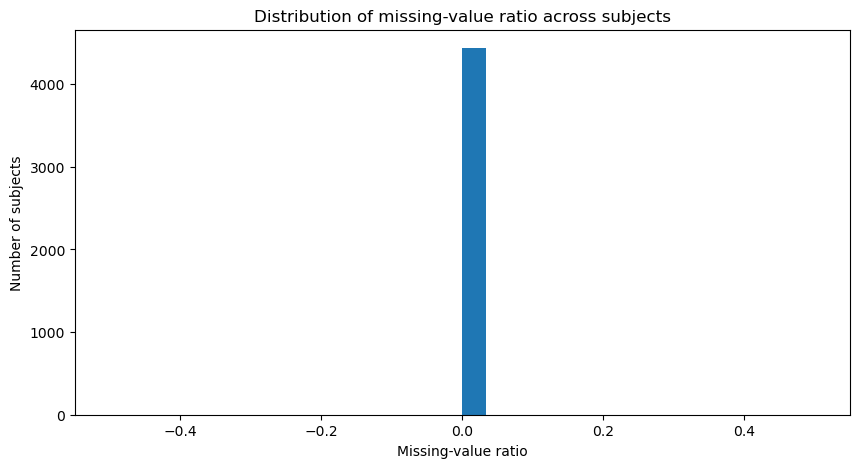

In [18]:
# Missing value analysis on selected signal columns

missing_rows = []

for i, ts in enumerate(CMI_timeseries_dataset):
    signal_data = ts[signal_cols]
    
    n_values = signal_data.size
    n_missing = signal_data.isna().sum().sum()
    
    missing_rows.append({
        "series_index": i,
        "subject_id": ts[id_col].iloc[0],
        "target": ts[target_col].iloc[0],
        "n_missing": n_missing,
        "missing_ratio": n_missing / n_values
    })

missing_df = pd.DataFrame(missing_rows)

print("Missing value summary across subjects:")
display(missing_df["missing_ratio"].describe())

print("\nNumber of subjects with at least one missing value:")
print((missing_df["n_missing"] > 0).sum())

print("\nTop 10 subjects by missing ratio:")
display(missing_df.sort_values("missing_ratio", ascending=False).head(10))

plt.figure(figsize=(10, 5))
plt.hist(missing_df["missing_ratio"], bins=30)
plt.title("Distribution of missing-value ratio across subjects")
plt.xlabel("Missing-value ratio")
plt.ylabel("Number of subjects")
plt.show()

### Missing-value analysis

We analyzed missing values in the selected signal variables: `X`, `Y`, `Z`, `enmo`, `anglez`, and `light`.

The missing-value ratio is equal to zero for all 4,437 subjects. Moreover, the number of subjects with at least one missing value is also zero. This means that the selected time-series signals are complete and no missing-value imputation is required for these variables.

This is an important preprocessing result because it allows us to preserve the original temporal structure of the data without introducing artificial values through interpolation, forward filling, backward filling or mean imputation.

Although no missing values are present in the selected signals, further preprocessing is still required. In particular, we need to analyze anomalous observations, flat segments, non-wear intervals and the scale differences between variables before applying clustering or classification algorithms.

Non-wear summary across subjects:


count    4437.000000
mean        0.025895
std         0.138289
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: non_wear_ratio, dtype: float64


Number of subjects with at least one non-wear interval:
179

Top 10 subjects by non-wear ratio:


,series_index,subject_id,target,n_non_wear,non_wear_ratio
1843,1843,981,1,200,1.0
2163,2163,3746,1,200,1.0
2889,2889,142,0,200,1.0
2567,2567,894,1,200,1.0
796,796,2206,1,200,1.0
1587,1587,2922,0,200,1.0
2651,2651,956,0,200,1.0
4399,4399,3114,1,200,1.0
2959,2959,1017,1,200,1.0
2906,2906,717,1,200,1.0



Average non-wear ratio by class:


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,2957.0,0.020916,0.122589,0.0,0.0,0.0,0.0,1.0
1,1480.0,0.035841,0.164845,0.0,0.0,0.0,0.0,1.0


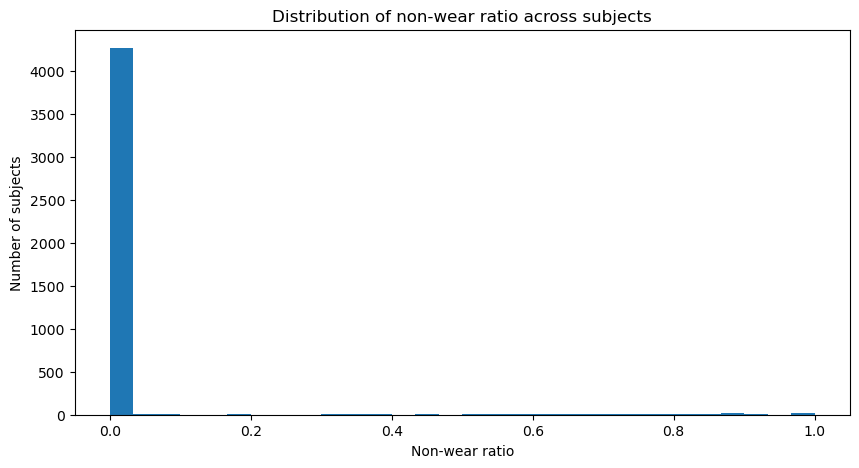

In [19]:
# Analysis of non-wear intervals

non_wear_rows = []

for i, ts in enumerate(CMI_timeseries_dataset):
    n_time_steps = ts.shape[0]
    n_non_wear = (ts["non-wear_flag"] == 1).sum()
    
    non_wear_rows.append({
        "series_index": i,
        "subject_id": ts[id_col].iloc[0],
        "target": ts[target_col].iloc[0],
        "n_non_wear": n_non_wear,
        "non_wear_ratio": n_non_wear / n_time_steps
    })

non_wear_df = pd.DataFrame(non_wear_rows)

print("Non-wear summary across subjects:")
display(non_wear_df["non_wear_ratio"].describe())

print("\nNumber of subjects with at least one non-wear interval:")
print((non_wear_df["n_non_wear"] > 0).sum())

print("\nTop 10 subjects by non-wear ratio:")
display(non_wear_df.sort_values("non_wear_ratio", ascending=False).head(10))

print("\nAverage non-wear ratio by class:")
display(non_wear_df.groupby("target")["non_wear_ratio"].describe())

plt.figure(figsize=(10, 5))
plt.hist(non_wear_df["non_wear_ratio"], bins=30)
plt.title("Distribution of non-wear ratio across subjects")
plt.xlabel("Non-wear ratio")
plt.ylabel("Number of subjects")
plt.show()

### Non-wear interval analysis

We analyzed the `non-wear_flag` variable, which indicates intervals in which the device was likely not worn. This variable is important because non-wear periods may produce low or artificial activity signals that should not be interpreted as true subject behavior.

The results show that 179 out of 4,437 subjects have at least one non-wear interval. Therefore, non-wear is present only in a minority of subjects. The median and the 75th percentile of the non-wear ratio are equal to zero, meaning that at least 75% of the subjects have no non-wear intervals.

However, some subjects have a non-wear ratio equal to 1. This means that all 200 time steps were flagged as non-wear for those subjects. These cases are potentially problematic, because their time series may not represent valid behavioral information.

The average non-wear ratio is slightly higher for class `1` than for class `0`, but both classes have median equal to zero. Therefore, non-wear does not appear to be a general characteristic of one class, although it may affect some individual subjects.

For preprocessing, we should not automatically remove all subjects with any non-wear interval, because some subjects may have only a small number of affected time steps. A more reasonable strategy is to identify subjects with a high non-wear ratio and decide whether to remove or flag them. Subjects with a very high non-wear ratio, especially those with `non_wear_ratio = 1`, should be treated carefully before clustering or classification.

In [20]:
# Count how many subjects exceed different non-wear thresholds

thresholds = [0, 0.05, 0.10, 0.25, 0.50, 0.80, 1.00]

threshold_summary = []

for threshold in thresholds:
    n_subjects = (non_wear_df["non_wear_ratio"] > threshold).sum()
    threshold_summary.append({
        "threshold": threshold,
        "n_subjects_above_threshold": n_subjects,
        "percentage": n_subjects / len(non_wear_df) * 100
    })

threshold_summary_df = pd.DataFrame(threshold_summary)

display(threshold_summary_df)


,threshold,n_subjects_above_threshold,percentage
0,0.00,179,4.034257
1,0.05,170,3.831418
2,0.10,167,3.763804
3,0.25,158,3.560965
4,0.50,127,2.862294
5,0.80,67,1.510029
6,1.00,0,0.000000


### Choice of a non-wear threshold

We computed how many subjects would be affected by different non-wear thresholds. The results show that 179 subjects, corresponding to approximately 4.03% of the dataset, have at least one non-wear interval.

However, the number of subjects remains relatively similar for low thresholds: 170 subjects have more than 5% non-wear intervals and 167 subjects have more than 10%. This suggests that, when non-wear is present, it is often not limited to only one or two isolated intervals.

A stricter threshold of 50% identifies 127 subjects, corresponding to approximately 2.86% of the dataset. These subjects have non-wear flags in more than half of their time series and are therefore likely to have unreliable temporal information. An even stricter threshold of 80% identifies 67 subjects, approximately 1.51% of the dataset.

For this reason, a reasonable preprocessing strategy is to remove or flag subjects with `non_wear_ratio > 0.50`. This threshold removes clearly problematic time series while preserving subjects with only limited non-wear intervals. We avoid removing all subjects with any non-wear interval, because this would discard observations that may still contain mostly valid temporal information.

In [21]:
# Define subjects to keep/remove based on non-wear ratio

non_wear_threshold = 0.50

subjects_to_remove_non_wear = non_wear_df[
    non_wear_df["non_wear_ratio"] > non_wear_threshold
]["series_index"].tolist()

subjects_to_keep_non_wear = non_wear_df[
    non_wear_df["non_wear_ratio"] <= non_wear_threshold
]["series_index"].tolist()

print("Non-wear threshold:", non_wear_threshold)
print("Subjects to remove:", len(subjects_to_remove_non_wear))
print("Subjects to keep:", len(subjects_to_keep_non_wear))

print("\nClass distribution before removal:")
display(target_df["target_value"].value_counts().sort_index())

print("\nClass distribution after removing high non-wear subjects:")
target_after_non_wear = target_df.loc[
    target_df["series_index"].isin(subjects_to_keep_non_wear),
    "target_value"
]
display(target_after_non_wear.value_counts().sort_index())

Non-wear threshold: 0.5
Subjects to remove: 127
Subjects to keep: 4310

Class distribution before removal:


target_value
0    2957
1    1480
Name: count, dtype: int64


Class distribution after removing high non-wear subjects:


target_value
0    2888
1    1422
Name: count, dtype: int64

### Effect of high non-wear removal on class distribution

Using the threshold `non_wear_ratio > 0.50`, we identify 127 subjects to remove and retain 4,310 subjects for the following analyses.

Before removal, the class distribution was:

- Class `0`: 2,957 subjects
- Class `1`: 1,480 subjects

After removing high non-wear subjects, the class distribution becomes:

- Class `0`: 2,888 subjects
- Class `1`: 1,422 subjects

The removal therefore affects both classes in a relatively balanced way and does not substantially alter the original class distribution. This is important because preprocessing should not introduce additional class imbalance or systematically remove one class more than the other.

The retained dataset will be used for the following preprocessing and analysis steps, while the removed subjects are excluded because more than half of their time series is flagged as non-wear and is therefore likely to be unreliable.

In [22]:
# Create filtered dataset after removing high non-wear subjects

CMI_timeseries_filtered = [
    CMI_timeseries_dataset[i]
    for i in subjects_to_keep_non_wear
]

print("Original number of time series:", len(CMI_timeseries_dataset))
print("Filtered number of time series:", len(CMI_timeseries_filtered))

# Recreate target dataframe for the filtered dataset
filtered_target_values = []

for i, ts in enumerate(CMI_timeseries_filtered):
    filtered_target_values.append({
        "filtered_series_index": i,
        "subject_id": ts[id_col].iloc[0],
        "target_value": ts[target_col].iloc[0]
    })

filtered_target_df = pd.DataFrame(filtered_target_values)

print("\nFiltered target distribution:")
display(filtered_target_df["target_value"].value_counts().sort_index())

Original number of time series: 4437
Filtered number of time series: 4310

Filtered target distribution:


target_value
0    2888
1    1422
Name: count, dtype: int64

Shape of concatenated signal dataframe:
(862000, 9)

Descriptive statistics for selected signals:


,count,mean,std,min,25%,50%,75%,max
X,862000.0,-0.095968,0.544031,-8.022103,-0.576610,-0.234677,0.444123,1.360524
Y,862000.0,0.002495,0.354548,-2.084078,-0.232564,0.002196,0.238038,1.552069
Z,862000.0,-0.090951,0.405750,-1.042407,-0.356640,-0.114098,0.146721,8.018888
enmo,862000.0,0.058220,0.084944,0.000000,0.014981,0.031850,0.068190,7.033528
anglez,862000.0,-6.580246,28.206804,-89.859741,-23.553000,-7.845232,8.736501,89.706787
light,862000.0,54.099056,210.921768,0.000000,3.218811,8.377585,21.181442,2594.622070


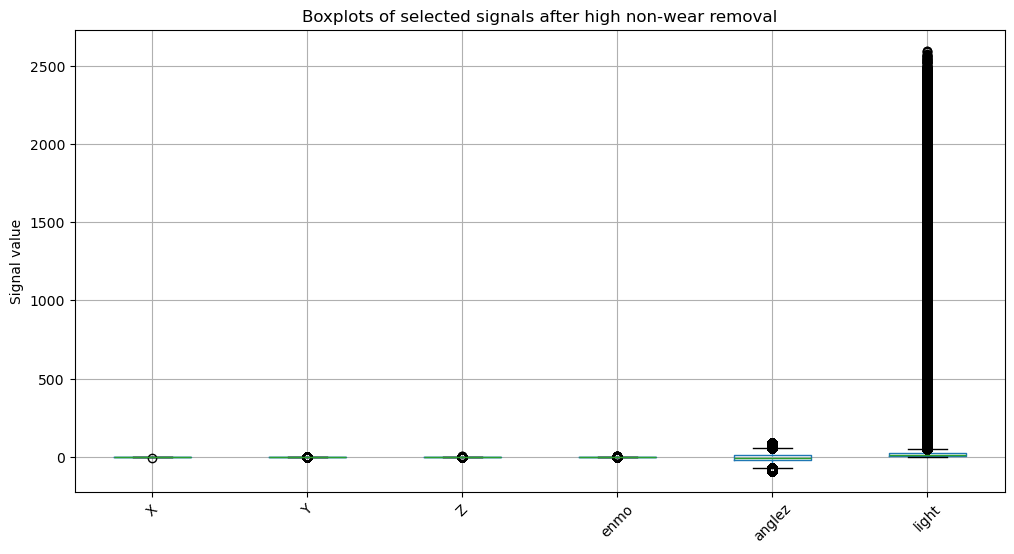

In [23]:
# Descriptive statistics of selected signals after high non-wear removal

all_signal_values = []

for i, ts in enumerate(CMI_timeseries_filtered):
    temp = ts[signal_cols].copy()
    temp["filtered_series_index"] = i
    temp["subject_id"] = ts[id_col].iloc[0]
    temp["target"] = ts[target_col].iloc[0]
    all_signal_values.append(temp)

signals_long_df = pd.concat(all_signal_values, ignore_index=True)

print("Shape of concatenated signal dataframe:")
print(signals_long_df.shape)

print("\nDescriptive statistics for selected signals:")
display(signals_long_df[signal_cols].describe().T)

# Boxplots for selected signals
plt.figure(figsize=(12, 6))
signals_long_df[signal_cols].boxplot()
plt.title("Boxplots of selected signals after high non-wear removal")
plt.ylabel("Signal value")
plt.xticks(rotation=45)
plt.show()

### Descriptive statistics and global boxplots

After removing subjects with high non-wear ratio, we concatenated all valid time points into a single dataframe. The resulting dataframe contains 862,000 rows, corresponding to 4,310 subjects observed over 200 time steps.

The descriptive statistics show that the selected signals have very different numerical scales and distributions. The accelerometer axes (`X`, `Y`, `Z`) are mostly concentrated around values between approximately `-1` and `1`, although `X` presents a very low minimum value that may correspond to an anomalous observation. The `enmo` variable is non-negative and mostly close to zero, but it also contains some large peaks. The `anglez` variable ranges approximately between `-90` and `90`, which is coherent with its interpretation as an angle-related variable.

The `light` variable is clearly the most skewed signal. Its median is relatively low, but its maximum is very large, indicating the presence of strong peaks. These peaks may represent real exposure to bright light rather than errors, so they should not be removed automatically without further inspection.

The global boxplot confirms that the variables are on very different scales. In particular, `light` dominates the plot and compresses the other variables visually. This indicates that scaling or normalization will be necessary before applying distance-based methods such as KNN, clustering, DTW-based comparisons or dimensionality reduction.

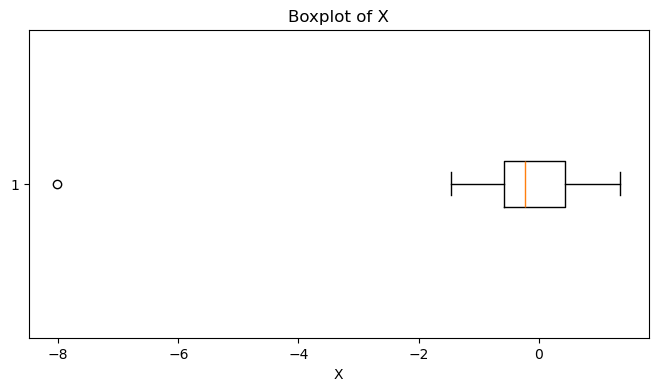

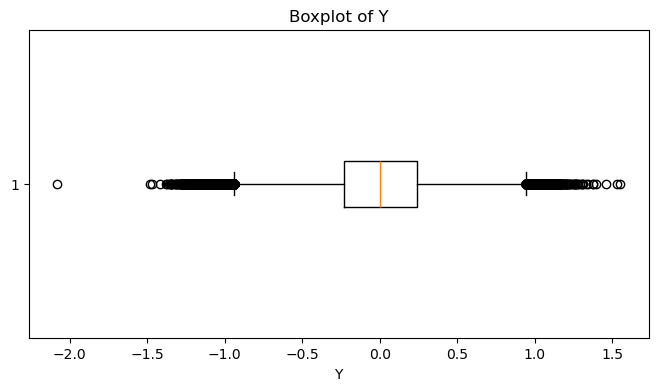

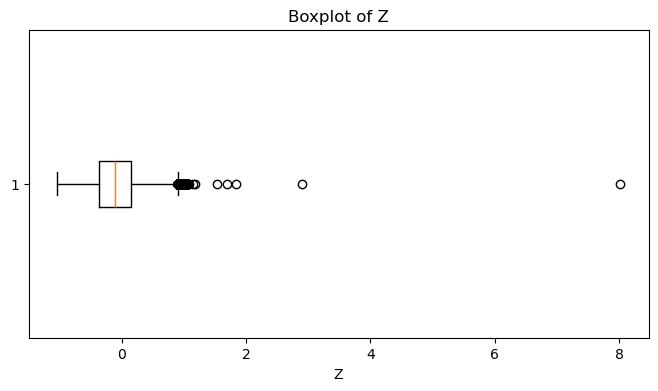

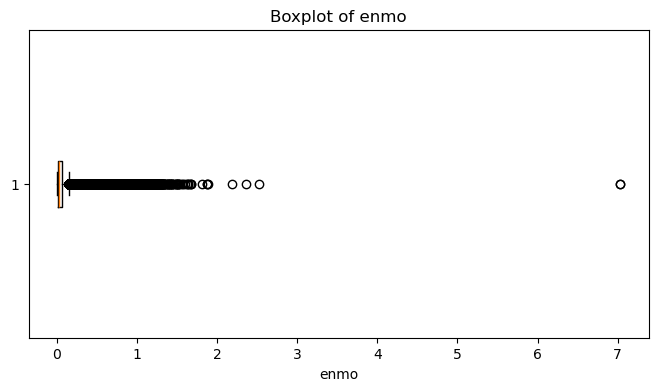

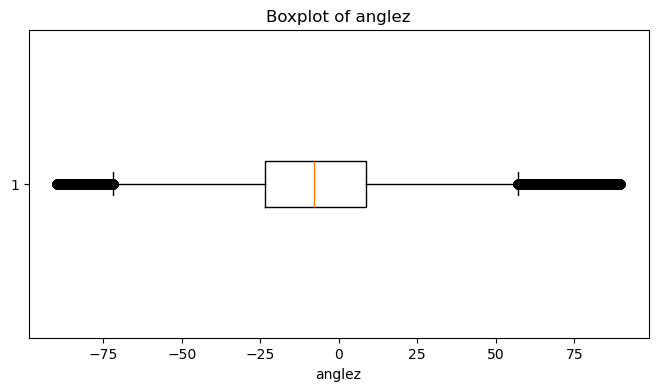

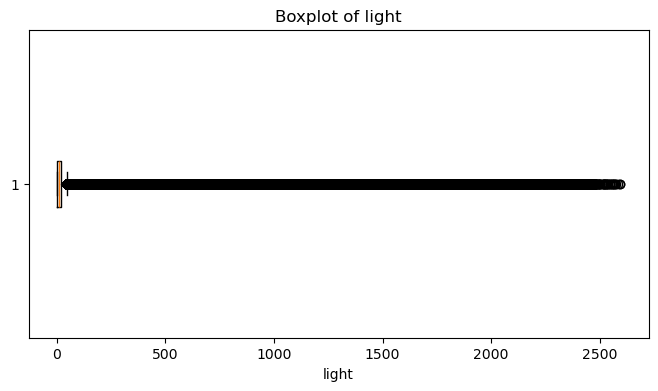

In [24]:
# Separate boxplot for each selected signal

for col in signal_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(signals_long_df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [25]:
# Quantify global IQR outliers for each selected signal

iqr_summary = []

for col in signal_cols:
    x = signals_long_df[col].dropna()
    
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_mask = (x < lower_bound) | (x > upper_bound)
    n_outliers = outlier_mask.sum()
    
    iqr_summary.append({
        "signal": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": n_outliers,
        "outlier_percentage": n_outliers / len(x) * 100
    })

iqr_summary_df = pd.DataFrame(iqr_summary)

display(iqr_summary_df)

,signal,q1,q3,iqr,lower_bound,upper_bound,n_outliers,outlier_percentage
0,X,-0.576610,0.444123,1.020733,-2.107710,1.975222,1,0.000116
1,Y,-0.232564,0.238038,0.470602,-0.938467,0.943941,3712,0.430626
2,Z,-0.356640,0.146721,0.503362,-1.111682,0.901764,11580,1.343387
3,enmo,0.014981,0.068190,0.053209,-0.064832,0.148003,70148,8.137819
4,anglez,-23.553000,8.736501,32.289501,-71.987253,57.170753,29926,3.471694
5,light,3.218811,21.181442,17.962631,-23.725135,48.125388,103082,11.958469


### Quantification of global IQR outliers

We quantified global outliers for each selected signal using the standard IQR rule. The results show that the number of detected outliers differs substantially across variables.

The `X` variable has only one IQR outlier, suggesting the presence of a single very extreme anomalous value. The `Y` and `Z` variables have relatively small outlier percentages, while `anglez` has a moderate number of tail observations.

The `enmo` variable has a larger percentage of IQR outliers. This is expected because `enmo` is mostly close to zero and activity peaks are naturally flagged as extreme values by a global IQR rule. However, these peaks may represent meaningful movement events rather than errors.

The `light` variable has the highest percentage of IQR outliers because its distribution is strongly right-skewed. High light values may correspond to real bright-light exposure, so removing them automatically would risk deleting meaningful information.

Therefore, the IQR rule is useful for exploratory purposes, but it should not be used blindly to remove all flagged observations. In time-series data, global extreme values must be distinguished from local anomalies and meaningful peaks.

In [26]:
# Inspect most extreme observations for each selected signal

extreme_rows = []

for col in signal_cols:
    x = signals_long_df[col]
    
    min_idx = x.idxmin()
    max_idx = x.idxmax()
    
    extreme_rows.append({
        "signal": col,
        "extreme_type": "minimum",
        "value": signals_long_df.loc[min_idx, col],
        "subject_id": signals_long_df.loc[min_idx, "subject_id"],
        "target": signals_long_df.loc[min_idx, "target"],
        "filtered_series_index": signals_long_df.loc[min_idx, "filtered_series_index"]
    })
    
    extreme_rows.append({
        "signal": col,
        "extreme_type": "maximum",
        "value": signals_long_df.loc[max_idx, col],
        "subject_id": signals_long_df.loc[max_idx, "subject_id"],
        "target": signals_long_df.loc[max_idx, "target"],
        "filtered_series_index": signals_long_df.loc[max_idx, "filtered_series_index"]
    })

extreme_values_df = pd.DataFrame(extreme_rows)

display(extreme_values_df)

,signal,extreme_type,value,subject_id,target,filtered_series_index
0,X,minimum,-8.022103,1044,0,2924
1,X,maximum,1.360524,699,0,1546
2,Y,minimum,-2.084078,3556,1,116
3,Y,maximum,1.552069,3309,1,1435
4,Z,minimum,-1.042407,978,0,55
5,Z,maximum,8.018888,2064,1,544
6,enmo,minimum,0.000000,3042,1,1
7,enmo,maximum,7.033528,1044,0,2924
8,anglez,minimum,-89.859741,1221,0,2611
9,anglez,maximum,89.706787,2592,0,1252


In [27]:
#!pip install sktime

Subject id: 2265
Target: 0
Signal: enmo
Number of detected anomalies: 17


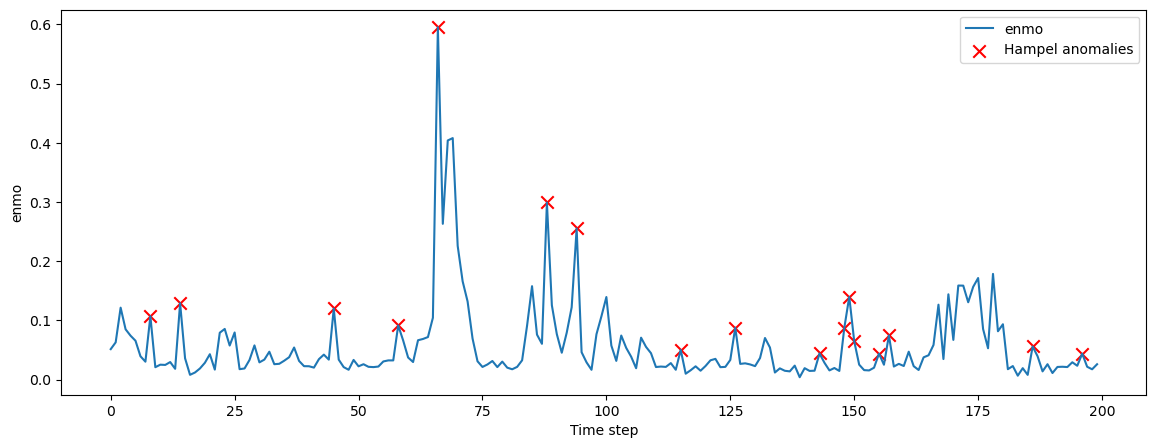

In [43]:
# Hampel Filter on one selected time series signal, following the professor's approach

from sktime.transformations.series.outlier_detection import HampelFilter

# Select one subject and one signal to inspect
example_idx = 0
signal_to_analyze = "enmo"

ts = CMI_timeseries_filtered[example_idx][signal_to_analyze]

# Hampel Filter
# Lower n_sigma = more sensitive detector
annotator = HampelFilter(
    window_length=12,
    n_sigma=3,
    return_bool=True
)

labels = annotator.fit_transform(ts).to_numpy()

print("Subject id:", CMI_timeseries_filtered[example_idx][id_col].iloc[0])
print("Target:", CMI_timeseries_filtered[example_idx][target_col].iloc[0])
print("Signal:", signal_to_analyze)
print("Number of detected anomalies:", labels.sum())

plt.figure(figsize=(14, 5))
plt.plot(ts.to_numpy(), label=signal_to_analyze)
plt.scatter(
    np.arange(len(labels))[labels],
    ts.to_numpy()[labels],
    color="red",
    marker="x",
    s=80,
    label="Hampel anomalies"
)
plt.xlabel("Time step")
plt.ylabel(signal_to_analyze)
plt.legend()
plt.show()

### Local anomaly detection with Hampel Filter

we applied the `HampelFilter` from `sktime` to one selected univariate time series. In this example, we analyzed the `enmo` signal for subject `2265`, whose target class is `0`.

The Hampel Filter detected 17 local anomalies. These are marked with red crosses in the plot. Unlike global boxplot outliers, Hampel anomalies are detected by comparing each observation with its local temporal neighborhood. Therefore, a point is considered anomalous if it strongly deviates from nearby values, not necessarily if it is globally extreme.

For the `enmo` signal, the detected anomalies mostly correspond to sharp activity peaks. These peaks may represent real short bursts of movement rather than data errors. Therefore, they should not be automatically removed at this stage.

This analysis shows that local anomaly detection is more appropriate for time-series data than using only global boxplots. The next step is to apply the same Hampel-based logic systematically across subjects and signals in order to quantify the amount of local anomalies in the dataset.

In [29]:
# Systematic Hampel anomaly analysis across all filtered subjects and selected signals

hampel_summary = []

for i, ts_df in enumerate(CMI_timeseries_filtered):
    total_anomalies = 0
    total_values = 0
    
    row = {
        "filtered_series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    }
    
    for signal in signal_cols:
        ts_signal = ts_df[signal]
        
        annotator = HampelFilter(
            window_length=12,
            n_sigma=3,
            return_bool=True
        )
        
        labels = annotator.fit_transform(ts_signal).to_numpy()
        
        n_anomalies = labels.sum()
        anomaly_ratio = n_anomalies / len(labels)
        
        row[f"{signal}_n_anomalies"] = n_anomalies
        row[f"{signal}_anomaly_ratio"] = anomaly_ratio
        
        total_anomalies += n_anomalies
        total_values += len(labels)
    
    row["total_n_anomalies"] = total_anomalies
    row["total_anomaly_ratio"] = total_anomalies / total_values
    
    hampel_summary.append(row)

hampel_summary_df = pd.DataFrame(hampel_summary)

print("Hampel anomaly summary across filtered subjects:")
display(hampel_summary_df["total_anomaly_ratio"].describe())

print("\nTop 10 subjects by total anomaly ratio:")
display(hampel_summary_df.sort_values("total_anomaly_ratio", ascending=False).head(10))

print("\nAverage total anomaly ratio by class:")
display(hampel_summary_df.groupby("target")["total_anomaly_ratio"].describe())

Hampel anomaly summary across filtered subjects:


count    4310.000000
mean        0.045366
std         0.010453
min         0.013333
25%         0.038333
50%         0.045000
75%         0.051667
max         0.104167
Name: total_anomaly_ratio, dtype: float64


Top 10 subjects by total anomaly ratio:


,filtered_series_index,subject_id,target,X_n_anomalies,X_anomaly_ratio,Y_n_anomalies,Y_anomaly_ratio,Z_n_anomalies,Z_anomaly_ratio,enmo_n_anomalies,enmo_anomaly_ratio,anglez_n_anomalies,anglez_anomaly_ratio,light_n_anomalies,light_anomaly_ratio,total_n_anomalies,total_anomaly_ratio
2634,2634,341,1,23,0.115,26,0.130,22,0.110,23,0.115,16,0.080,15,0.075,125,0.104167
3959,3959,3829,0,9,0.045,19,0.095,31,0.155,25,0.125,32,0.160,2,0.010,118,0.098333
3814,3814,367,1,24,0.120,18,0.090,13,0.065,25,0.125,15,0.075,18,0.090,113,0.094167
3319,3319,555,1,18,0.090,15,0.075,30,0.150,17,0.085,21,0.105,3,0.015,104,0.086667
3217,3217,1407,0,14,0.070,8,0.040,13,0.065,24,0.120,15,0.075,27,0.135,101,0.084167
198,198,63,1,15,0.075,20,0.100,17,0.085,22,0.110,19,0.095,7,0.035,100,0.083333
332,332,129,0,10,0.050,8,0.040,14,0.070,31,0.155,13,0.065,24,0.120,100,0.083333
76,76,3460,1,20,0.100,12,0.060,17,0.085,26,0.130,18,0.090,7,0.035,100,0.083333
4185,4185,601,1,5,0.025,11,0.055,15,0.075,43,0.215,15,0.075,9,0.045,98,0.081667
983,983,300,1,10,0.050,17,0.085,13,0.065,16,0.080,17,0.085,23,0.115,96,0.080000



Average total anomaly ratio by class:


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,2888.0,0.045072,0.010161,0.013333,0.037500,0.045,0.051667,0.098333
1,1422.0,0.045963,0.011002,0.013333,0.038333,0.045,0.052500,0.104167


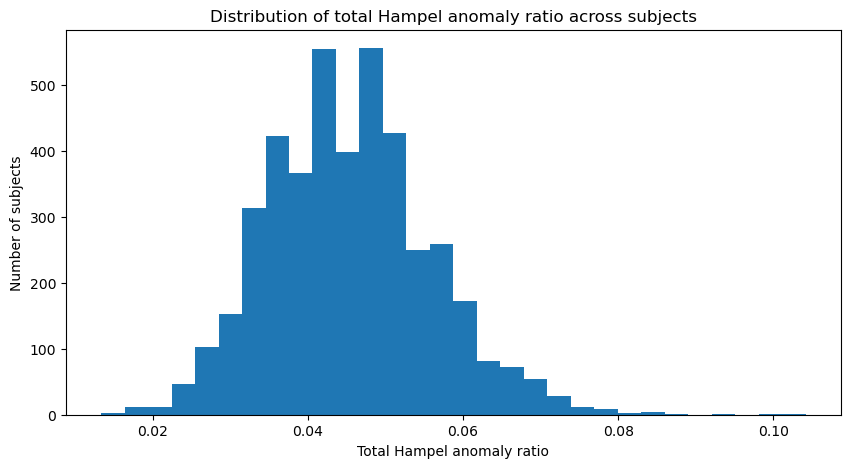

<Figure size 800x500 with 0 Axes>

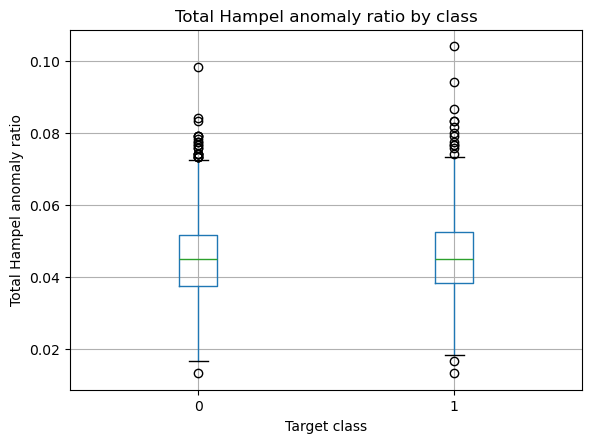

In [30]:
# Visualize distribution of Hampel anomaly ratios

plt.figure(figsize=(10, 5))
plt.hist(hampel_summary_df["total_anomaly_ratio"], bins=30)
plt.title("Distribution of total Hampel anomaly ratio across subjects")
plt.xlabel("Total Hampel anomaly ratio")
plt.ylabel("Number of subjects")
plt.show()

plt.figure(figsize=(8, 5))
hampel_summary_df.boxplot(column="total_anomaly_ratio", by="target")
plt.title("Total Hampel anomaly ratio by class")
plt.suptitle("")
plt.xlabel("Target class")
plt.ylabel("Total Hampel anomaly ratio")
plt.show()

### Distribution of Hampel anomaly ratios

The distribution of total Hampel anomaly ratios is centered around approximately 4–5% of the signal observations. Most subjects have an anomaly ratio between about 0.035 and 0.055, while only a small number of subjects present substantially higher values.

The boxplot by class shows that the anomaly-ratio distributions are very similar for class `0` and class `1`. The medians and interquartile ranges are almost overlapping. Class `1` shows a slightly wider upper tail, but the difference is not large enough to suggest a clear separation between the two target classes.

These results indicate that local anomalies are a common characteristic of the time series rather than a rare data-quality problem affecting only a few subjects. Therefore, Hampel-detected points should not be automatically removed. They may represent real movement peaks, changes in orientation, or light-exposure events.

For this reason, we keep the Hampel results as an exploratory diagnostic and avoid aggressive anomaly removal at this stage. The presence of local anomalies may be useful later for motif/discord discovery and shapelet-based classification.

In [31]:
# Define the current working dataset after non-wear filtering
# Hampel anomalies are kept, because they may represent meaningful temporal events

CMI_timeseries_preprocessed = CMI_timeseries_filtered.copy()

print("Number of time series in final working dataset:", len(CMI_timeseries_preprocessed))
print("Number of time steps per series:", CMI_timeseries_preprocessed[0].shape[0])
print("Selected signal columns:", signal_cols)

# Check final target distribution
final_target_values = [
    ts[target_col].iloc[0]
    for ts in CMI_timeseries_preprocessed
]

print("\nFinal target distribution:")
display(pd.Series(final_target_values).value_counts().sort_index())

Number of time series in final working dataset: 4310
Number of time steps per series: 200
Selected signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']

Final target distribution:


0    2888
1    1422
Name: count, dtype: int64

## Normalizations


In [32]:
# Create two scaled versions of the working dataset:
# 1. Global scaling: preserves between-subject differences
# 2. Subject-wise scaling: emphasizes within-subject temporal shape

from sklearn.preprocessing import StandardScaler

# ---------- Global scaling ----------
# Fit one scaler on all time points from all subjects
global_scaler = StandardScaler()

all_values_for_scaler = pd.concat(
    [ts[signal_cols] for ts in CMI_timeseries_preprocessed],
    axis=0,
    ignore_index=True
)

global_scaler.fit(all_values_for_scaler)

CMI_timeseries_global_scaled = []

for ts in CMI_timeseries_preprocessed:
    ts_scaled = ts.copy()
    ts_scaled[signal_cols] = global_scaler.transform(ts_scaled[signal_cols])
    CMI_timeseries_global_scaled.append(ts_scaled)


# ---------- Subject-wise scaling ----------
CMI_timeseries_subject_scaled = []

for ts in CMI_timeseries_preprocessed:
    ts_scaled = ts.copy()
    subject_scaler = StandardScaler()
    ts_scaled[signal_cols] = subject_scaler.fit_transform(ts_scaled[signal_cols])
    CMI_timeseries_subject_scaled.append(ts_scaled)


print("Raw filtered dataset:", len(CMI_timeseries_preprocessed))
print("Global-scaled dataset:", len(CMI_timeseries_global_scaled))
print("Subject-wise-scaled dataset:", len(CMI_timeseries_subject_scaled))

print("\nExample: global-scaled first subject")
display(CMI_timeseries_global_scaled[0][signal_cols].describe().T)

print("\nExample: subject-wise-scaled first subject")
display(CMI_timeseries_subject_scaled[0][signal_cols].describe().T)

Raw filtered dataset: 4310
Global-scaled dataset: 4310
Subject-wise-scaled dataset: 4310

Example: global-scaled first subject


,count,mean,std,min,25%,50%,75%,max
X,200.0,-0.778709,0.564696,-1.605181,-1.189076,-0.877998,-0.510706,1.515118
Y,200.0,0.116781,0.848056,-2.026027,-0.429884,0.128888,0.715382,2.159436
Z,200.0,-0.387199,0.685273,-2.171672,-0.930010,-0.312491,0.160721,0.829028
enmo,200.0,-0.002705,0.836175,-0.638381,-0.432514,-0.302813,0.124697,6.322810
anglez,200.0,-0.395096,0.693369,-2.513529,-0.904535,-0.272974,0.163805,0.740683
light,200.0,-0.094116,0.440693,-0.256205,-0.213397,-0.179951,-0.151832,3.770600



Example: subject-wise-scaled first subject


,count,mean,std,min,25%,50%,75%,max
X,200.0,1.102686e-08,1.002510,-1.467242,-0.728527,-0.176268,0.475789,4.072247
Y,200.0,-1.907349e-08,1.002509,-2.533072,-0.646227,0.014312,0.707622,2.414678
Z,200.0,0.000000e+00,1.002509,-2.610569,-0.794097,0.109293,0.801573,1.779262
enmo,200.0,9.536743e-09,1.002509,-0.762127,-0.515308,-0.359807,0.152746,7.583810
anglez,200.0,9.536743e-09,1.002509,-3.062943,-0.736575,0.176570,0.808088,1.642169
light,200.0,9.536743e-09,1.002509,-0.368728,-0.271344,-0.195260,-0.131294,8.791634


### Scaling strategies for time-series analysis

Since the selected variables have very different numerical scales, we created two standardized versions of the filtered dataset.

The first version is the globally scaled dataset. In this case, one `StandardScaler` is fitted using all time points from all subjects, and the same transformation is applied to every time series. This approach preserves between-subject differences in signal levels while preventing large-scale variables such as `light` or `anglez` from dominating distance-based methods.

The second version is the subject-wise scaled dataset. In this case, each subject is standardized independently, so each signal within each subject has approximately mean zero and standard deviation one. This removes subject-level magnitude differences and emphasizes the temporal shape of each signal.

Both versions are useful for different parts of the analysis. The globally scaled dataset is more appropriate for classification and clustering when between-subject differences may be informative. The subject-wise scaled dataset is more appropriate for shape-based analyses, such as motif/discord discovery and shapelet extraction, where the temporal pattern is more important than the absolute scale.

Therefore, both scaled datasets are retained for the following Module 3 tasks.

In [33]:
# Save preprocessed datasets and relevant metadata

import pickle

preprocessing_output = {
    "CMI_timeseries_preprocessed": CMI_timeseries_preprocessed,
    "CMI_timeseries_global_scaled": CMI_timeseries_global_scaled,
    "CMI_timeseries_subject_scaled": CMI_timeseries_subject_scaled,
    "signal_cols": signal_cols,
    "id_col": id_col,
    "target_col": target_col,
    "target_df": target_df,
    "filtered_target_df": filtered_target_df,
    "non_wear_df": non_wear_df,
    "hampel_summary_df": hampel_summary_df
}

output_path = "../dataset/CMI_timeseries_preprocessed_outputs.pkl"

with open(output_path, "wb") as f:
    pickle.dump(preprocessing_output, f)

print("Saved preprocessing output to:", output_path)

Saved preprocessing output to: ../dataset/CMI_timeseries_preprocessed_outputs.pkl


Different normalization strategies were considered for the time-series data, including offset translation, amplitude scaling and detrending. In this work, we adopted standardization because it provides a simple and interpretable way to handle both offset and scale differences.

Two standardized versions of the dataset were created. First, a global standardization was applied by fitting the scaler on all subjects and time steps. This version preserves between-subject differences and is therefore suitable for clustering and classification tasks based on distances.

Second, a subject-wise standardization was applied independently to each subject. This version removes subject-specific offsets and amplitude differences, emphasizing the temporal shape of each signal. It is therefore more appropriate for shape-based analyses such as Matrix Profile, motif/discord discovery and shapelet extraction.

We did not apply detrending or smoothing globally, because slow temporal changes and local peaks may represent meaningful behavioral patterns rather than noise. Removing them could eliminate relevant information for motif discovery, discord detection and classification.

In [34]:
# Optional approximation: Piecewise Aggregate Approximation (PAA)

def paa_transform_series(x, n_segments):
    """
    Apply Piecewise Aggregate Approximation to a univariate time series.
    The time series is divided into n_segments and each segment is replaced by its mean.
    """
    x = np.asarray(x)
    segments = np.array_split(x, n_segments)
    return np.array([segment.mean() for segment in segments])


def paa_transform_dataset(time_series_list, signal_cols, n_segments=50):
    """
    Apply PAA to all selected signals for each subject.
    Returns a 3D array with shape:
    n_subjects x n_segments x n_signals
    """
    X_paa = []

    for ts_df in time_series_list:
        subject_paa = []

        for signal in signal_cols:
            x_paa = paa_transform_series(ts_df[signal].values, n_segments=n_segments)
            subject_paa.append(x_paa)

        subject_paa = np.array(subject_paa).T
        X_paa.append(subject_paa)

    return np.array(X_paa)


n_segments = 50

X_paa_global = paa_transform_dataset(
    CMI_timeseries_global_scaled,
    signal_cols=signal_cols,
    n_segments=n_segments
)

X_paa_subject = paa_transform_dataset(
    CMI_timeseries_subject_scaled,
    signal_cols=signal_cols,
    n_segments=n_segments
)

print("Global-scaled PAA shape:", X_paa_global.shape)
print("Subject-wise-scaled PAA shape:", X_paa_subject.shape)

Global-scaled PAA shape: (4310, 50, 6)
Subject-wise-scaled PAA shape: (4310, 50, 6)


### PAA approximation results

We applied Piecewise Aggregate Approximation (PAA) to both the global-scaled and subject-wise-scaled versions of the dataset.

The resulting shapes are:

- Global-scaled PAA dataset: `(4310, 50, 6)`
- Subject-wise-scaled PAA dataset: `(4310, 50, 6)`

This means that each of the 4,310 subjects is represented by 50 temporal segments and 6 selected signals. Since the original time series had 200 time steps, PAA reduces the temporal length from 200 to 50, corresponding to a 75% reduction.

Each PAA segment summarizes 4 original time steps. Since each original time step corresponds to 30 minutes, each PAA segment represents approximately 2 hours.

This approximation preserves the general temporal shape of the signals while reducing computational complexity. It can be useful for expensive time-series methods such as DTW-based clustering, DTW-based classification and shapelet extraction.

In [35]:
# SAX approximation for the enmo signal

from scipy.stats import norm

def sax_transform_1d(x, alphabet_size=5):
    """
    Transform a 1D time series into a SAX symbolic sequence.
    
    The input is assumed to be approximately standardized.
    Breakpoints are computed from the standard normal distribution.
    """
    x = np.asarray(x, dtype=float)
    
    # Gaussian breakpoints
    breakpoints = norm.ppf(
        np.linspace(0, 1, alphabet_size + 1)[1:-1]
    )
    
    alphabet = np.array(list("abcdefghijklmnopqrstuvwxyz")[:alphabet_size])
    
    symbols = alphabet[np.digitize(x, breakpoints)]
    
    return symbols


signal_to_sax = "enmo"
signal_idx = signal_cols.index(signal_to_sax)

alphabet_size = 5

# Apply SAX to the PAA subject-wise representation
sax_sequences = []

for i in range(X_paa_subject.shape[0]):
    x_paa = X_paa_subject[i, :, signal_idx]
    sax_seq = sax_transform_1d(x_paa, alphabet_size=alphabet_size)
    
    sax_sequences.append({
        "series_index": i,
        "subject_id": CMI_timeseries_preprocessed[i][id_col].iloc[0],
        "target": CMI_timeseries_preprocessed[i][target_col].iloc[0],
        "sax_sequence": "".join(sax_seq)
    })

sax_df = pd.DataFrame(sax_sequences)

display(sax_df.head())

,series_index,subject_id,target,sax_sequence
0,0,2265,0,dcccbccbbbbcbbcceecbbdeecccbbbbcbbbbbdbbbcdedb...
1,1,3042,1,bbbbbbbbbbbbbbdbcebdbbcbbbbbcecdbccbdeedececdc...
2,2,1647,1,bbbbbbbbbccbbbccbbbbbcbbcceebbeeecbdddbbbbdbdd...
3,3,736,0,bbbbbbbbbbbbbbcbbcccbcbcdcdddccdececcedbbdbddd...
4,4,1044,0,bbbbbabbbabbbbcbcbeedbbbbcccccceeeccddededcccc...


## SAX approximation

In addition to PAA, we also considered Symbolic Aggregate approXimation (SAX). SAX transforms a numerical time series into a symbolic sequence. This is useful because it provides a compact and interpretable representation of temporal patterns.

In our workflow, SAX is applied after subject-wise scaling and PAA. The subject-wise scaling removes subject-specific offsets and amplitude differences, while PAA reduces the temporal length from 200 time steps to 50 segments. SAX then discretizes the PAA values into a finite alphabet.

This symbolic representation can be useful for identifying frequent symbolic patterns and for the optional sequential pattern mining task. However, SAX is not used as the main representation for Matrix Profile motif/discord discovery, because discretization may remove some local numerical details and short anomalies.

### SAX representation results

We applied SAX to the PAA representation of the subject-wise standardized `enmo` signal. The resulting dataframe contains one symbolic sequence for each subject.

Each SAX sequence represents the temporal evolution of the `enmo` signal using a finite alphabet. Since SAX was applied after PAA with 50 segments, each symbolic sequence has length 50. Each symbol corresponds to one approximately 2-hour temporal segment.

The symbolic representation provides a compact and interpretable approximation of the original time series. Lower symbols correspond to lower standardized activity levels, while higher symbols correspond to higher standardized activity levels.

This representation is not used as the main input for Matrix Profile motif/discord discovery, because discretization may remove short local variations. However, it can be useful for approximate pattern analysis and for optional sequential pattern mining.

SAX sequence length distribution:


sax_length
50    4310
Name: count, dtype: int64

,symbol,count,percentage
0,a,6938,3.219490
1,b,95981,44.538747
2,c,58476,27.135035
3,d,28579,13.261717
4,e,25526,11.845012


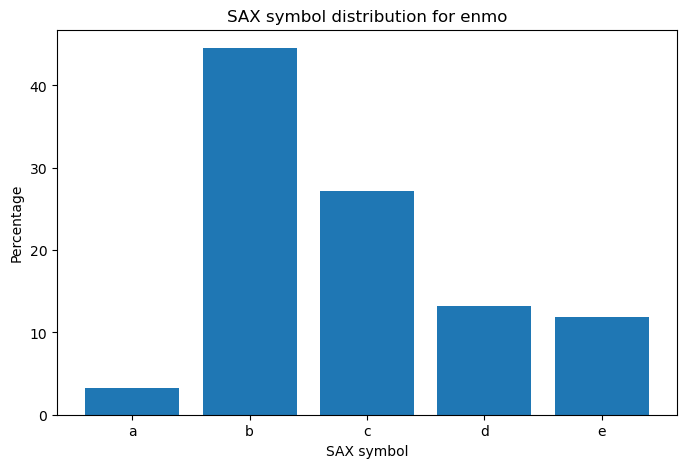

In [36]:
# Check SAX sequence length and symbol distribution

sax_df["sax_length"] = sax_df["sax_sequence"].apply(len)

print("SAX sequence length distribution:")
display(sax_df["sax_length"].value_counts().sort_index())

all_symbols = "".join(sax_df["sax_sequence"].tolist())

symbol_counts = pd.Series(list(all_symbols)).value_counts().sort_index()
symbol_distribution = pd.DataFrame({
    "symbol": symbol_counts.index,
    "count": symbol_counts.values,
    "percentage": symbol_counts.values / symbol_counts.values.sum() * 100
})

display(symbol_distribution)

plt.figure(figsize=(8, 5))
plt.bar(symbol_distribution["symbol"], symbol_distribution["percentage"])
plt.title("SAX symbol distribution for enmo")
plt.xlabel("SAX symbol")
plt.ylabel("Percentage")
plt.show()

### SAX symbol distribution

We checked the distribution of SAX symbols for the `enmo` signal after subject-wise scaling and PAA approximation.

The most frequent symbols are `b` and `c`, while the extreme low symbol `a` is relatively rare. Higher activity symbols, especially `d` and `e`, are less frequent than `b` and `c`, but still appear in a meaningful proportion of the segments.

This distribution is coherent with the nature of the `enmo` signal. Since `enmo` represents movement/activity intensity, most temporal segments correspond to low or moderate activity, while high-activity segments occur less frequently.

The SAX representation therefore provides a compact symbolic description of the activity profile. It can be useful for approximate pattern analysis and for optional sequential pattern mining, while the original subject-wise standardized time series remains the main representation for Matrix Profile motif and discord discovery.

In [38]:
# Save PAA and SAX outputs

approximation_output = {
    "X_paa_global": X_paa_global,
    "X_paa_subject": X_paa_subject,
    "sax_df": sax_df,
    "signal_cols": signal_cols,
    "id_col": id_col,
    "target_col": target_col,
    "n_segments": n_segments,
    "alphabet_size": alphabet_size,
    "signal_to_sax": signal_to_sax
}

output_path = "../dataset/CMI_timeseries_approximation_outputs.pkl"

with open(output_path, "wb") as f:
    pickle.dump(approximation_output, f)

print("Saved approximation outputs to:", output_path)

Saved approximation outputs to: ../dataset/CMI_timeseries_approximation_outputs.pkl


### Saving approximation outputs

The PAA and SAX representations were saved to a separate pickle file. This allows us to reuse the approximation outputs in later notebooks without recomputing them.

The saved objects include the global-scaled PAA representation, the subject-wise-scaled PAA representation, and the SAX dataframe for the `enmo` signal.

In [39]:
# Frequent symbolic patterns from SAX sequences

from collections import Counter

def extract_symbolic_patterns(sequence, pattern_length):
    """
    Extract all contiguous symbolic patterns of fixed length
    from a SAX sequence.
    """
    return [
        sequence[i:i + pattern_length]
        for i in range(len(sequence) - pattern_length + 1)
    ]


pattern_length = 4

all_patterns = []
patterns_by_class = {0: [], 1: []}

for _, row in sax_df.iterrows():
    sequence = row["sax_sequence"]
    target = row["target"]
    
    patterns = extract_symbolic_patterns(sequence, pattern_length)
    
    all_patterns.extend(patterns)
    patterns_by_class[target].extend(patterns)

# Overall pattern frequencies
overall_counter = Counter(all_patterns)

overall_patterns_df = pd.DataFrame(
    overall_counter.items(),
    columns=["pattern", "count"]
).sort_values("count", ascending=False)

overall_patterns_df["percentage"] = (
    overall_patterns_df["count"] / overall_patterns_df["count"].sum() * 100
)

print("Top 20 most frequent SAX patterns overall:")
display(overall_patterns_df.head(20))


# Pattern frequencies by class
class_pattern_tables = {}

for cls, patterns in patterns_by_class.items():
    counter = Counter(patterns)
    
    df = pd.DataFrame(
        counter.items(),
        columns=["pattern", "count"]
    ).sort_values("count", ascending=False)
    
    df["percentage"] = df["count"] / df["count"].sum() * 100
    df["target"] = cls
    
    class_pattern_tables[cls] = df

print("\nTop 20 most frequent SAX patterns for class 0:")
display(class_pattern_tables[0].head(20))

print("\nTop 20 most frequent SAX patterns for class 1:")
display(class_pattern_tables[1].head(20))

Top 20 most frequent SAX patterns overall:


,pattern,count,percentage
7,bbbb,30166,14.891642
8,bbbc,6776,3.345017
6,cbbb,5255,2.594165
101,cccc,4361,2.152836
9,bbcb,4037,1.992891
12,bbcc,4021,1.984993
10,bcbb,3703,1.828010
5,ccbb,3210,1.584637
73,bccc,2915,1.439009
1,cccb,2634,1.300291



Top 20 most frequent SAX patterns for class 0:


,pattern,count,percentage,target
7,bbbb,20517,15.115371,0
8,bbbc,4529,3.336624,0
6,cbbb,3415,2.515913,0
68,cccc,2886,2.126186,0
12,bbcc,2757,2.031149,0
9,bbcb,2619,1.929481,0
10,bcbb,2371,1.746773,0
5,ccbb,2132,1.570696,0
33,bccc,1982,1.460187,0
1,cccb,1769,1.303265,0



Top 20 most frequent SAX patterns for class 1:


,pattern,count,percentage,target
0,bbbb,9649,14.437262,1
13,bbbc,2247,3.362061,1
12,cbbb,1840,2.753090,1
117,cccc,1475,2.206961,1
10,bbcb,1418,2.121675,1
11,bcbb,1332,1.992998,1
34,bbcc,1264,1.891253,1
35,ccbb,1078,1.612951,1
82,bccc,933,1.395996,1
145,cccb,865,1.294251,1


### Frequent SAX patterns

We extracted frequent symbolic patterns of length 4 from the SAX representation of the `enmo` signal. Since SAX was applied after PAA with 50 segments, each symbol represents approximately 2 hours. Therefore, a symbolic pattern of length 4 corresponds to an approximate 8-hour temporal pattern.

The most frequent pattern overall is `bbbb`, representing a long interval of relatively low-to-moderate standardized activity. Other frequent patterns are also mostly composed of the symbols `b` and `c`, such as `bbbc`, `cbbb`, `cccc`, `bbcb`, and `bbcc`.

This result is coherent with the SAX symbol distribution, where `b` and `c` were the most common symbols. It suggests that the `enmo` signal is often characterized by relatively stable low-to-moderate activity segments.

The class-specific pattern frequencies are very similar. In both class `0` and class `1`, the most frequent pattern is `bbbb`, with comparable percentages. Therefore, these simple frequent symbolic patterns describe the general temporal structure of the dataset, but they do not appear to be strongly discriminative between the two target classes.

This SAX-based analysis is useful as an approximate symbolic description of the data and can support optional sequential pattern mining. However, it does not replace the Matrix Profile analysis used for motif and discord discovery.

In [40]:
# Check unique subject IDs and window counts after preprocessing/filtering

id_summary_final = []

for i, ts_df in enumerate(CMI_timeseries_subject_scaled):
    id_summary_final.append({
        "series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    })

id_summary_final_df = pd.DataFrame(id_summary_final)

window_counts_final = (
    id_summary_final_df
    .groupby("subject_id")
    .size()
    .reset_index(name="n_windows")
    .sort_values("n_windows", ascending=False)
)

print("Number of time-series windows:", len(id_summary_final_df))
print("Number of unique subject IDs:", id_summary_final_df["subject_id"].nunique())
print("Average windows per subject:", window_counts_final["n_windows"].mean())

display(window_counts_final.describe())
display(window_counts_final.head(20))

Number of time-series windows: 4310
Number of unique subject IDs: 375
Average windows per subject: 11.493333333333334


,subject_id,n_windows
count,375.000000,375.000000
mean,1871.240000,11.493333
std,1182.848351,10.892245
min,3.000000,1.000000
25%,830.500000,1.000000
50%,1721.000000,8.000000
75%,2821.000000,21.000000
max,3957.000000,36.000000


,subject_id,n_windows
203,2043,36
198,1935,35
21,210,34
265,2712,34
83,736,33
157,1397,33
67,633,33
151,1328,33
36,339,32
95,835,32


### Window-level structure of the dataset

The preprocessed dataset contains 4,310 time-series windows associated with 375 unique subject IDs. Therefore, the unit of analysis in this notebook is the individual time-series window, not the unique subject.

Several subjects contribute multiple windows to the dataset. The average number of windows per subject is approximately 11.5, with a maximum of 36 windows for a single subject. Target labels are consistent within each subject ID, so repeated IDs do not indicate contradictory labels.

This distinction is important for interpretation. Motif and discord discovery using Matrix Profile is performed at the window level, because the method analyzes repeated and anomalous subsequences within each individual time series. We do not concatenate windows from the same subject, since this could create artificial transitions between unrelated temporal windows.

For later supervised classification tasks, however, this structure must be handled carefully. Train/test splits should be performed at the subject level, using `subject_id` as a grouping variable, in order to avoid data leakage between training and test sets.

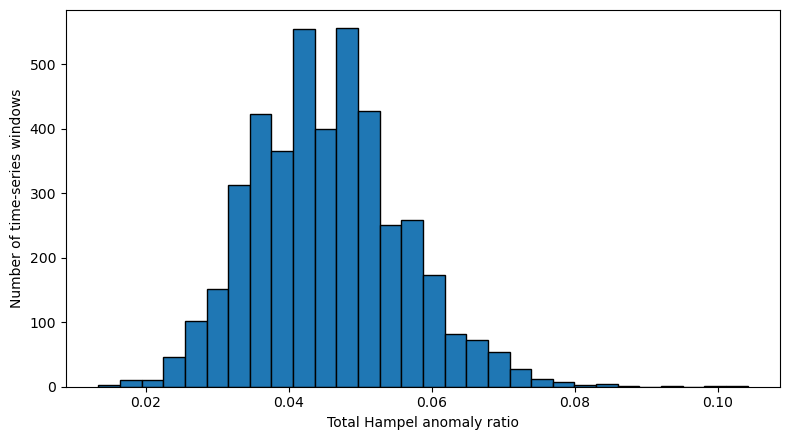

In [42]:
# Plot distribution of total Hampel anomaly ratio across time-series windows

plt.figure(figsize=(8, 4.5))

plt.hist(
    hampel_summary_df["total_anomaly_ratio"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Total Hampel anomaly ratio")
plt.ylabel("Number of time-series windows")

plt.tight_layout()
plt.show()

In [44]:
# Time-series component inspection: level, trend, seasonality proxy, and noise proxy

from sklearn.linear_model import LinearRegression

component_rows = []

time_index = np.arange(200).reshape(-1, 1)
daily_lag = 48  # 48 half-hour steps = 24 hours

for i, ts_df in enumerate(CMI_timeseries_filtered):
    row = {
        "series_index": i,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    }
    
    for signal in signal_cols:
        x = ts_df[signal].to_numpy(dtype=float)
        
        # Level: average value of the series
        row[f"{signal}_level"] = np.mean(x)
        
        # Trend: slope of a linear regression over time
        model = LinearRegression()
        model.fit(time_index, x)
        row[f"{signal}_trend_slope"] = model.coef_[0]
        
        # Variability / heteroskedasticity proxy
        row[f"{signal}_std"] = np.std(x)
        
        # Noise / roughness proxy: variability of first differences
        dx = np.diff(x)
        row[f"{signal}_diff_std"] = np.std(dx)
        row[f"{signal}_mean_abs_diff"] = np.mean(np.abs(dx))
        
        # Seasonality proxy: autocorrelation at daily lag
        if len(x) > daily_lag and np.std(x[:-daily_lag]) > 0 and np.std(x[daily_lag:]) > 0:
            row[f"{signal}_acf_lag48"] = np.corrcoef(x[:-daily_lag], x[daily_lag:])[0, 1]
        else:
            row[f"{signal}_acf_lag48"] = np.nan
    
    component_rows.append(row)

ts_components_df = pd.DataFrame(component_rows)

print("Time-series component descriptor dataframe shape:", ts_components_df.shape)
display(ts_components_df.head())

Time-series component descriptor dataframe shape: (4310, 39)


,series_index,subject_id,target,X_level,X_trend_slope,X_std,X_diff_std,X_mean_abs_diff,X_acf_lag48,Y_level,...,anglez_std,anglez_diff_std,anglez_mean_abs_diff,anglez_acf_lag48,light_level,light_trend_slope,light_std,light_diff_std,light_mean_abs_diff,light_acf_lag48
0,0,2265,0,-0.519637,0.001343,0.306463,0.191015,0.144007,-0.195183,0.043908,...,19.514105,15.680555,11.754587,0.163237,34.234751,-0.151213,92.780570,64.147306,18.293811,-0.024498
1,1,3042,1,-0.515332,-0.003748,0.420018,0.292022,0.179550,-0.005970,-0.013799,...,20.486422,21.841347,14.811428,0.104679,65.402747,0.483165,264.852441,173.691709,38.730715,-0.047080
2,2,1647,1,-0.300400,-0.000481,0.419799,0.404384,0.282945,-0.114207,-0.147930,...,24.352669,21.982448,16.066851,-0.144843,145.861165,0.468437,408.112613,232.113827,69.080916,-0.134066
3,3,736,0,0.046304,0.001665,0.483653,0.277050,0.192992,-0.237413,0.130333,...,22.264178,18.924506,12.294979,-0.084156,19.400756,0.154043,71.374249,65.149441,15.696765,-0.014042
4,4,1044,0,0.453723,0.001852,0.390693,0.252745,0.174307,-0.265587,0.118501,...,21.263070,16.660674,12.636389,-0.055413,16.429163,-0.016295,10.350284,10.060626,5.244170,-0.044146


In [45]:
# Summary of component descriptors for enmo

enmo_component_cols = [
    "enmo_level",
    "enmo_trend_slope",
    "enmo_std",
    "enmo_diff_std",
    "enmo_mean_abs_diff",
    "enmo_acf_lag48"
]

display(ts_components_df[enmo_component_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
enmo_level,4310.0,0.058220,0.025023,0.000020,0.040769,0.054975,0.071597,0.229622
enmo_trend_slope,4310.0,0.000239,0.000289,-0.001008,0.000058,0.000194,0.000367,0.002677
enmo_std,4310.0,0.070565,0.040158,0.000149,0.042044,0.062473,0.089288,0.512439
enmo_diff_std,4310.0,0.060334,0.032239,0.000174,0.038935,0.055123,0.075316,0.700913
enmo_mean_abs_diff,4310.0,0.033512,0.014491,0.000025,0.023211,0.031565,0.041424,0.127218
enmo_acf_lag48,4310.0,-0.002950,0.123538,-0.507527,-0.085119,-0.016765,0.067120,0.848252


In [46]:
# Component descriptors by class for enmo

display(
    ts_components_df
    .groupby("target")[enmo_component_cols]
    .agg(["mean", "median", "std"])
)

enmo_level                     enmo_trend_slope                      \
             mean    median       std             mean    median       std   
target                                                                       
0        0.062007  0.058811  0.025129         0.000275  0.000228  0.000297   
1        0.050528  0.045670  0.022967         0.000166  0.000130  0.000258   

        enmo_std                     enmo_diff_std                      \
            mean    median       std          mean    median       std   
target                                                                   
0       0.075192  0.067757  0.040517      0.063898  0.058645  0.032280   
1       0.061169  0.051973  0.037723      0.053096  0.047010  0.030926   

       enmo_mean_abs_diff                     enmo_acf_lag48            \
                     mean    median       std           mean    median   
target                                                                   
0                0.035425  0.033348  0.014623      -0.002751 -0.015900   
1                0.029627  0.026837  0.013408      -0.003354 -0.019038   

                  
             std  
target            
0       0.122621  
1       0.125421

In [47]:
# Check candidate filtered/scaled lists in preprocessing notebook

for name in sorted(globals().keys()):
    if "time" in name.lower() or "filtered" in name.lower() or "scaled" in name.lower():
        obj = globals()[name]
        try:
            print(f"{name}: type={type(obj)}, len={len(obj)}, shape={getattr(obj, 'shape', None)}")
        except Exception:
            print(f"{name}: type={type(obj)}, shape={getattr(obj, 'shape', None)}")

CMI_timeseries_dataset: type=<class 'list'>, len=4437, shape=None
CMI_timeseries_filtered: type=<class 'list'>, len=4310, shape=None
CMI_timeseries_global_scaled: type=<class 'list'>, len=4310, shape=None
CMI_timeseries_preprocessed: type=<class 'list'>, len=4310, shape=None
CMI_timeseries_subject_scaled: type=<class 'list'>, len=4310, shape=None
filtered_target_df: type=<class 'pandas.core.frame.DataFrame'>, len=4310, shape=(4310, 3)
filtered_target_values: type=<class 'list'>, len=4310, shape=None
n_time_steps: type=<class 'int'>, shape=None
time_index: type=<class 'numpy.ndarray'>, len=200, shape=(200, 1)
time_steps: type=<class 'numpy.ndarray'>, len=200, shape=(200,)
ts_scaled: type=<class 'pandas.core.frame.DataFrame'>, len=200, shape=(200, 13)


In [48]:
# Save metadata aligned with filtered / scaled / PAA time-series windows

ts_list_for_metadata = CMI_timeseries_subject_scaled

assert len(ts_list_for_metadata) == len(filtered_target_values), (
    f"Length mismatch: ts_list={len(ts_list_for_metadata)}, "
    f"targets={len(filtered_target_values)}"
)

metadata_rows = []

for window_pos, ts_df in enumerate(ts_list_for_metadata):
    metadata_rows.append({
        "window_pos": window_pos,
        "subject_id": ts_df[id_col].iloc[0],
        "target": ts_df[target_col].iloc[0]
    })

metadata_filtered_df = pd.DataFrame(metadata_rows)

print("Metadata shape:", metadata_filtered_df.shape)
display(metadata_filtered_df.head())

print("Target distribution:")
display(metadata_filtered_df["target"].value_counts().sort_index())

metadata_filtered_df.to_pickle("../dataset/CMI_timeseries_metadata_filtered.pkl")

Metadata shape: (4310, 3)


,window_pos,subject_id,target
0,0,2265,0
1,1,3042,1
2,2,1647,1
3,3,736,0
4,4,1044,0


Target distribution:


target
0    2888
1    1422
Name: count, dtype: int64